# Projeto 1 - Insper AI 

In [1]:
import pandas as pd
df = pd.read_csv("cars.csv", low_memory=False)
df.head(10)

,id,ref_code,maker,first_reg,listed_yr,listed_mo,odo,disp,gearbox,fuel,...,doors,seats,paint,power_bhp,econ_mpg,length_mm,annual_tax,entry_price,pct_of_list,price
0,A6796895,M1288,Bentley,2000.0,2018,4,60000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,145000.0,0.1483,21500
1,A6544792,M1288,Bentley,2002.0,2018,6,44000,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,450.0,13.7 mpg,5390.0,315,149000.0,0.1930,28750
2,A9945056,M1288,Bentley,2002.0,2017,11,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,400.0,14.7 mpg,5390.0,315,149000.0,0.2013,29999
3,A7702534,M1288,Bentley,2003.0,2018,4,14000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,NaN,NaN,5390.0,NaN,151500.0,0.2307,34948
4,A1024660,M1288,Bentley,2003.0,2017,11,61652,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,NaN,NaN,5390.0,NaN,151500.0,0.1753,26555
5,A6714845,M1288,Bentley,2002.0,2017,12,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,450.0,13.7 mpg,5390.0,315,149000.0,0.1674,24950
6,A5108990,M1288,Bentley,2002.0,2018,8,67000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,450.0,13.7 mpg,5390.0,NaN,149000.0,0.2013,29995
7,A5499375,M1288,Bentley,2003.0,2018,4,99200,6.8L,Automatic,Petrol,...,4.0,5.0,Black,NaN,NaN,5390.0,NaN,151500.0,0.1482,22450
8,A7439592,M1288,Bentley,2003.0,2018,2,27541,6.8L,Automatic,Petrol,...,4.0,4.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1782,26990
9,A4767271,M1288,Bentley,2003.0,2017,11,38000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1980,29995


## Análise exploratória (superficial)



Visão geral da base: tamanho, tipos, valores faltantes, colunas que precisam de limpeza e distribuição dos dois alvos (`price` e `gearbox`).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)
df.info()

(170150, 21)
<class 'pandas.DataFrame'>
RangeIndex: 170150 entries, 0 to 170149
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           170150 non-null  str    
 1   ref_code     170150 non-null  str    
 2   maker        170150 non-null  str    
 3   first_reg    170145 non-null  float64
 4   listed_yr    170150 non-null  int64  
 5   listed_mo    170150 non-null  int64  
 6   odo          169472 non-null  str    
 7   disp         169011 non-null  str    
 8   gearbox      170033 non-null  str    
 9   fuel         169800 non-null  str    
 10  body         169440 non-null  str    
 11  doors        166646 non-null  float64
 12  seats        165319 non-null  float64
 13  paint        150865 non-null  str    
 14  power_bhp    148271 non-null  float64
 15  econ_mpg     141809 non-null  str    
 16  length_mm    152138 non-null  float64
 17  annual_tax   139864 non-null  str    
 18  entry_price  144352 no

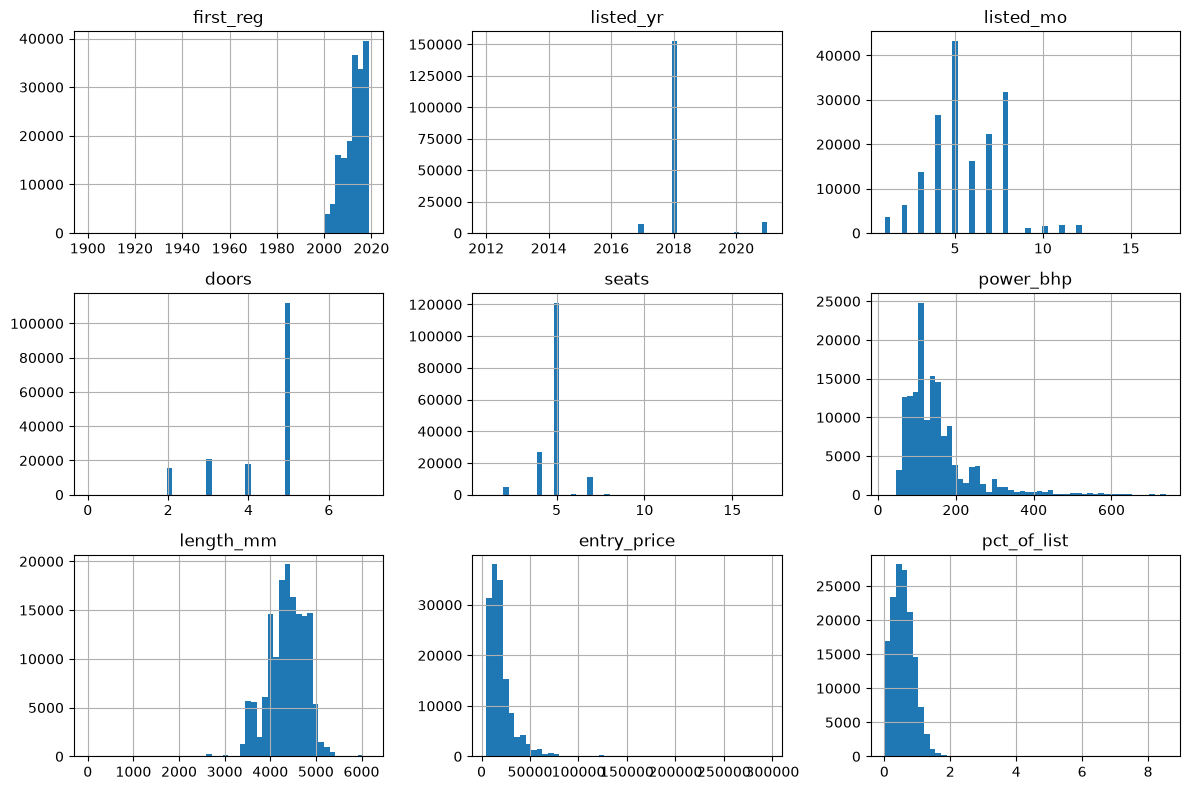

In [3]:
df.hist(bins=50, figsize=(12, 8)) 
plt.tight_layout() 
plt.show()

### Valores faltantes

In [4]:
faltantes = df.isna().mean().sort_values(ascending=False)
faltantes[faltantes > 0].mul(100).round(1).to_frame("% faltante")

,% faltante
annual_tax,17.8
econ_mpg,16.7
pct_of_list,15.4
entry_price,15.2
power_bhp,12.9
paint,11.3
length_mm,10.6
seats,2.8
doors,2.1
disp,0.7


### Colunas numéricas guardadas como texto


`price`, `odo`, `disp`, `econ_mpg` e `annual_tax` vêm como texto (sufixos como `L`, `mpg`, `mile(s)`, `*`, ou o valor `"Uknown"` em `price`). Abaixo, os valores que não viram número diretamente.

In [5]:
for col in ["price", "odo", "disp", "econ_mpg", "annual_tax"]:
    s = df[col].dropna().astype(str)
    nao_num = s[pd.to_numeric(s, errors="coerce").isna()]
    print(f"{col}: {len(nao_num)} valores não numéricos | exemplos: {nao_num.value_counts().head(5).to_dict()}")

price: 914 valores não numéricos | exemplos: {'Uknown': 914}
odo: 207 valores não numéricos | exemplos: {'1 mile': 207}
disp: 169011 valores não numéricos | exemplos: {'2.0L': 40908, '1.6L': 26332, '3.0L': 15174, '1.2L': 13350, '1.4L': 12784}
econ_mpg: 141809 valores não numéricos | exemplos: {'47.1 mpg': 5511, '62.8 mpg': 5495, '55.4 mpg': 5258, '47.9 mpg': 5072, '54.3 mpg': 4511}
annual_tax: 21719 valores não numéricos | exemplos: {' 140*': 20063, ' 130*': 1126, '*': 401, ' 0*': 129}


In [6]:
# Conversão rápida só para a exploração (a limpeza definitiva fica para o pipeline)
eda = df.copy()
eda["price"] = pd.to_numeric(eda["price"], errors="coerce")
eda["odo"] = pd.to_numeric(eda["odo"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")
eda["disp"] = pd.to_numeric(eda["disp"].str.rstrip("L"), errors="coerce")
eda["econ_mpg"] = pd.to_numeric(eda["econ_mpg"].str.replace("mpg", ""), errors="coerce")
eda["annual_tax"] = pd.to_numeric(eda["annual_tax"].str.replace("*", "", regex=False), errors="coerce")
eda["idade"] = eda["listed_yr"] - eda["first_reg"]

eda.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
first_reg,170145.0,2012.69,4.50,1900.00,2010.00,2014.00,2016.00,2019.00
listed_yr,170150.0,2018.12,0.74,2012.00,2018.00,2018.00,2018.00,2021.00
listed_mo,170150.0,5.61,2.08,1.00,4.00,5.00,7.00,17.00
odo,169472.0,48182.55,42992.03,0.00,14354.00,39117.00,74600.00,6363342.00
disp,169011.0,11.56,145.66,0.30,1.40,1.80,2.00,6900.00
doors,166646.0,4.36,1.02,0.00,4.00,5.00,5.00,7.00
seats,165319.0,4.89,0.86,1.00,5.00,5.00,5.00,17.00
power_bhp,148271.0,148.19,80.85,17.00,99.00,128.00,171.00,740.00
econ_mpg,141809.0,51.26,13.42,9.80,42.20,50.40,60.10,200.00
length_mm,152138.0,4366.60,420.18,0.00,4083.00,4387.00,4672.00,6165.00


### Variáveis categóricas

In [7]:
cat_cols = ["maker", "ref_code", "gearbox", "fuel", "body", "paint"]
eda[cat_cols].nunique().to_frame("categorias distintas")

,categorias distintas
maker,88
ref_code,513
gearbox,3
fuel,13
body,18
paint,22


In [8]:
for col in ["gearbox", "fuel", "body"]:
    print(eda[col].value_counts(dropna=False), "\n")

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64 

fuel
Diesel                             83053
Petrol                             81148
Hybrid  Petrol/Electric             3767
Electric                             703
Hybrid  Petrol/Electric Plug-in      462
NaN                                  350
Petrol Hybrid                        298
Petrol Plug-in Hybrid                185
Hybrid  Diesel/Electric               81
Diesel Hybrid                         34
Hybrid  Diesel/Electric Plug-in       34
Bi Fuel                               25
Petrol Ethanol                         8
Diesel Plug-in Hybrid                  2
Name: count, dtype: int64 

body
Hatchback          67035
SUV                39354
Saloon             14542
MPV                13775
Estate             11533
Coupe              10901
Convertible         8846
Pickup              2455
NaN                  710
Combi Van            450
Pa

In [9]:
eda["maker"].value_counts().head(15)

maker
Ford             21045
Audi             14296
Vauxhall         13577
BMW              12080
Volkswagen       11917
Toyota            8013
Peugeot           7112
Nissan            6098
Mazda             5463
Jaguar            5137
Mercedes-Benz     5015
Kia               4999
Renault           4984
SKODA             4568
Volvo             4519
Name: count, dtype: int64

### Alvo 1: `price`

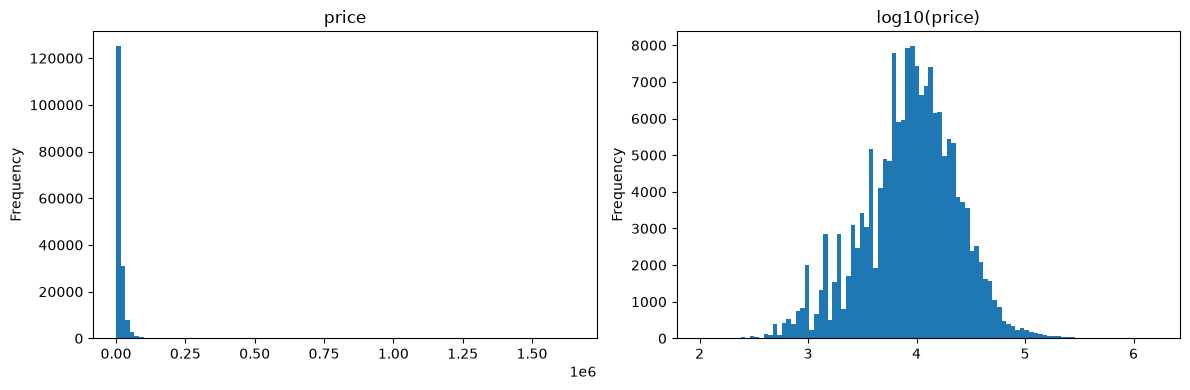

count     169236.0
mean       14104.0
std        20662.0
min          100.0
1%           695.0
25%         4990.0
50%         9395.0
75%        16995.0
99%        79950.0
max      1650000.0
Name: price, dtype: float64

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda["price"].plot.hist(bins=100, ax=axes[0], title="price")
np.log10(eda["price"]).plot.hist(bins=100, ax=axes[1], title="log10(price)")
plt.tight_layout()
plt.show()

eda["price"].describe(percentiles=[.01, .25, .5, .75, .99]).round(0)

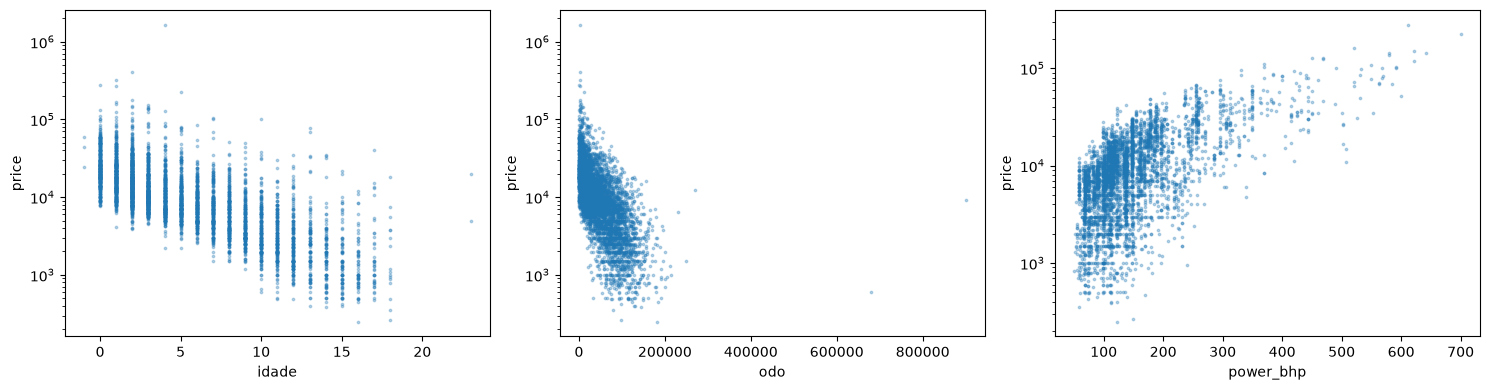

idade         -0.343933
odo           -0.328904
econ_mpg      -0.166858
doors         -0.152275
seats         -0.125222
listed_mo     -0.038701
disp           0.018878
listed_yr      0.101949
annual_tax     0.185979
length_mm      0.333384
first_reg      0.346075
pct_of_list    0.599356
power_bhp      0.695483
entry_price    0.796869
Name: price, dtype: float64

In [11]:
# Relação do preço com algumas numéricas (amostra para o gráfico ficar leve)
amostra = eda.sample(5000, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["idade", "odo", "power_bhp"]):
    ax.scatter(amostra[col], amostra["price"], s=3, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.set_ylabel("price")
plt.tight_layout()
plt.show()

eda.select_dtypes("number").corr()["price"].drop("price").sort_values()

### Alvo 2: `gearbox`

In [12]:
print(eda["gearbox"].value_counts(normalize=True).round(3))

# Proporção de automáticos por algumas categorias
for col in ["fuel", "body"]:
    tab = (eda.assign(auto=eda["gearbox"].eq("Automatic"))
              .groupby(col)["auto"].agg(["mean", "size"])
              .query("size >= 100").sort_values("mean", ascending=False))
    print(tab.round(3), "\n")

gearbox
Manual            0.640
Automatic         0.359
Semi-Automatic    0.001
Name: proportion, dtype: float64
                                  mean   size
fuel                                         
Hybrid  Petrol/Electric Plug-in  1.000    462
Petrol Plug-in Hybrid            1.000    185
Electric                         0.994    703
Petrol Hybrid                    0.990    298
Hybrid  Petrol/Electric          0.967   3767
Diesel                           0.411  83053
Petrol                           0.262  81148 

              mean   size
body                     
Panel Van    0.769    221
Saloon       0.640  14542
Coupe        0.586  10901
SUV          0.501  39354
Estate       0.416  11533
Convertible  0.395   8846
Pickup       0.349   2455
MPV          0.293  13775
Combi Van    0.209    450
Hatchback    0.177  67035 



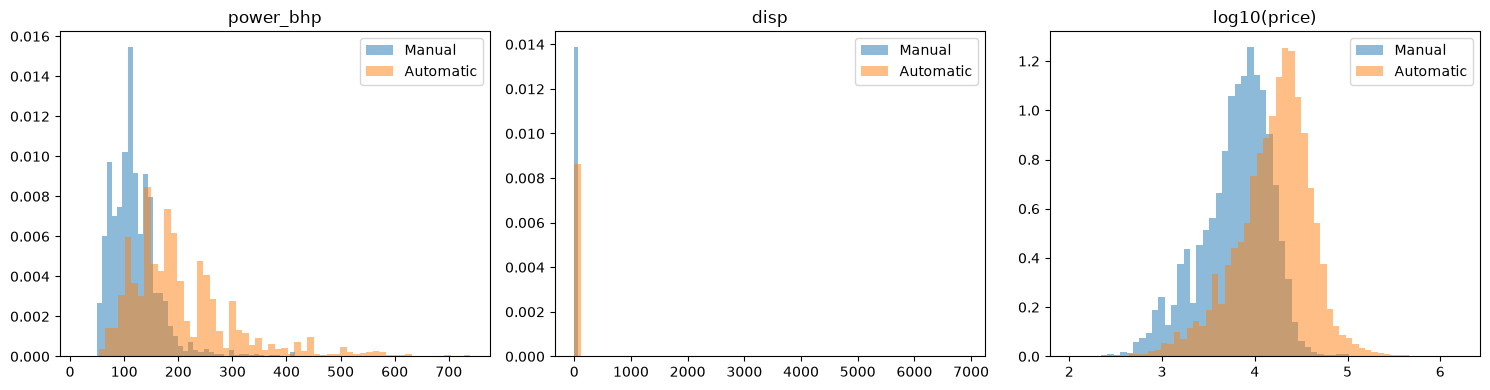

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["power_bhp", "disp", "price"]):
    for g in ["Manual", "Automatic"]:
        vals = eda.loc[eda["gearbox"] == g, col].dropna()
        if col == "price":
            vals = np.log10(vals)
        ax.hist(vals, bins=60, alpha=0.5, density=True, label=g)
    ax.set_title(col if col != "price" else "log10(price)")
    ax.legend()
plt.tight_layout()
plt.show()

### Primeiras observações


- **170 mil anúncios, 21 colunas.** Várias colunas numéricas estão como texto (`price`, `odo`, `disp`, `econ_mpg`, `annual_tax`) e precisam de limpeza.
- **`price` tem 914 valores `"Uknown"`** — essas linhas não servem para treinar o modelo de preço. A distribuição é bem assimétrica; `log(price)` fica muito mais comportada.
- **`pct_of_list` = `price / entry_price`**: usa o próprio alvo, então é **vazamento** e não pode entrar no modelo de preço (nem estará disponível num anúncio novo).
- **`gearbox`**: ~64% Manual, ~36% Automatic, e só 110 `Semi-Automatic` (decidir se descarta ou agrupa). Potência, cilindrada e preço separam bem as classes.
- **Faltantes** de até ~18% em `annual_tax`, `econ_mpg`, `entry_price`, `power_bhp`, `length_mm` e `paint`.
- **Anomalias**: `listed_mo` tem um valor 17; `body` tem 5 linhas `"Manual"`; `fuel` tem variações de escrita do mesmo tipo (ex.: `Hybrid  Petrol/Electric` vs `Petrol Hybrid`); `odo` tem valores como `"1 mile"`.
- **Alta cardinalidade**: `ref_code` (513) e `maker` (88) exigem cuidado na codificação, especialmente porque o conjunto de avaliação tem composição diferente.

## Limpeza da base de dados




Na EDA encontramos vários problemas na base. Nesta parte, tratamos **um problema de cada vez**, sempre no mesmo ciclo:

1. **O que vimos** — a observação e a hipótese sobre a causa;
2. **Investigação** — código que testa a hipótese;
3. **Decisão** — o que fazemos e por quê.

Durante a investigação **não alteramos a base**: só olhamos. No final, todas as decisões são reunidas em uma única função, `limpar()`.

Por que uma função? Porque a **mesma limpeza precisa ser aplicada ao arquivo de avaliação** na FINAL — PREDICTION SECTION. Para isso dar certo, a função segue três regras:

- **Não aprende nada dos dados** (nenhuma média, mediana ou contagem). Assim, aplicá-la a um arquivo novo dá exatamente o mesmo tratamento, sem depender da composição da base.
- **Não apaga linhas.** Valores impossíveis viram `NaN`. Na avaliação precisamos prever *todos* os anúncios, então a limpeza não pode descartar nenhum.
- **Não quebra se faltar coluna.** O arquivo de avaliação provavelmente não tem `price` nem `gearbox`.

In [14]:
import re

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)

(170150, 21)


### Problema 1 — `pct_of_list` 


**O que vimos:** o dicionário de dados define `pct_of_list` como `price / entry_price`. Se isso for verdade, essa coluna **contém o alvo** do Modelo 1: sabendo `pct_of_list` e `entry_price`, o preço sai por uma multiplicação.

**Hipótese a testar:** `pct_of_list` é exatamente `price / entry_price` em todas as linhas.

In [15]:
# O dicionário diz que pct_of_list = price / entry_price. Vamos conferir.
preco_num = pd.to_numeric(df["price"], errors="coerce")
razao_recalculada = preco_num / df["entry_price"]

tem_os_dois = df["pct_of_list"].notna() & razao_recalculada.notna()
bate = (razao_recalculada[tem_os_dois] - df.loc[tem_os_dois, "pct_of_list"]).abs() < 0.001

print("linhas com pct_of_list preenchido:", tem_os_dois.sum())
print("% em que pct_of_list = price / entry_price:", round(bate.mean() * 100, 2))
print("linhas com price desconhecido mas pct_of_list preenchido:",
      (preco_num.isna() & df["pct_of_list"].notna()).sum())

linhas com pct_of_list preenchido: 143907
% em que pct_of_list = price / entry_price: 100.0
linhas com price desconhecido mas pct_of_list preenchido: 0


**Resultado:** nas 143.907 linhas com a coluna preenchida, `pct_of_list` bate com `price / entry_price` em **100%** dos casos. E quando o preço é desconhecido, `pct_of_list` também está vazio: ela é calculada *a partir* do preço.

**Decisão: remover `pct_of_list` da base, para os dois modelos.**

- **Modelo 1:** usar essa coluna é vazamento. O modelo teria um erro quase zero no treino, mas num anúncio novo essa coluna não existe (para calculá-la, precisaríamos saber o preço, que é justamente o que queremos sugerir).
- **Modelo 2:** a coluna carrega a informação do preço. Como vamos decidir mais adiante se o preço entra no modelo de câmbio, não faz sentido deixar ele entrar "escondido" por aqui.

### Problema 2 — `price` como texto e preços extremos


**O que vimos:** `price` veio como texto, porque algumas linhas não têm número. A distribuição também é muito assimétrica: vai de £100 a £1,65 milhão.

**Perguntas:**
1. Quais valores não são número?
2. Os preços extremos são erros de digitação ou carros reais?

In [16]:
# Quais valores de price não são números?
nao_numericos = df.loc[preco_num.isna(), "price"]
print(nao_numericos.value_counts(dropna=False))

price
Uknown    914
Name: count, dtype: int64


In [17]:
# Os anúncios mais baratos e mais caros fazem sentido?
contexto = ["maker", "first_reg", "listed_yr", "odo", "entry_price", "price"]
aux = df.assign(price_num=preco_num).sort_values("price_num")

print("10 mais baratos:")
print(aux[contexto].head(10))
print("\n10 mais caros:")
print(aux.dropna(subset=["price_num"])[contexto].tail(10))

10 mais baratos:
             maker  first_reg  listed_yr     odo  entry_price price
142922    Vauxhall     2004.0       2018  115000       9825.0   100
90257      Renault     2002.0       2018   78451       7370.0   100
21563         Ford     2003.0       2018   61545       6370.0   100
148123    Vauxhall     2011.0       2018   70000       8940.0   100
17031         Ford     2004.0       2018   89000       9830.0   125
22350         Ford     2004.0       2018  100000       6632.0   150
151680  Volkswagen     2001.0       2018  215000      10570.0   150
90932      Renault     2006.0       2018     NaN       7350.0   175
142816    Vauxhall     2001.0       2018  147000      10115.0   180
114005       Smart     2002.0       2018   72941       6170.0   180

10 mais caros:
             maker  first_reg  listed_yr    odo  entry_price    price
84688      Porsche     2018.0       2018     50      77891.0   549995
6040       Ferrari     2011.0       2018  18668          NaN   599995
6043     

**Resultado:**

- O único valor não numérico é `"Uknown"` , em **914 linhas**.
- Os **mais baratos** (£100–£180) são, em sua maioria, carros populares de 2001–2006 com bastante quilometragem. São preços de "carro para desmanche", plausíveis. Um ou outro é suspeito (um Vauxhall de 2011 por £100), mas não há como provar que é erro.
- Os **mais caros** são Bugatti, Pagani, Koenigsegg e Ferrari: hipercarros reais, com preços reais.

**Decisões:**

- `"Uknown"` vira `NaN`. Essas 914 linhas **não servem para treinar o Modelo 1**, mas **continuam na base**: elas têm câmbio e servem para o Modelo 2.
- **Os preços extremos são mantidos.** Motivos:
  1. Não conseguimos distinguir com segurança o que é erro do que é carro barato de verdade;
  2. São muito poucos: menos de 20 anúncios abaixo de £200, em 169 mil;
  3. Vamos modelar `log(price)`, então os extremos não dominam o treino;
  4. Remover os carros de luxo só "esconderia" o problema. Preferimos deixá-los e **mostrar na análise de erros** que o modelo erra mais neles, o que vai para o escopo de validade.

### Problema 3 — Categorias de `gearbox`


**O que vimos:** além de `Automatic` e `Manual`, existe `Semi-Automatic`, e há linhas sem câmbio. O enunciado pede só duas classes para o modelo 2.

**Pergunta:** quem são os semiautomáticos? Eles se parecem mais com automáticos ou com manuais?

In [18]:
print(df["gearbox"].value_counts(dropna=False))
print("\nQuem são os Semi-Automatic:")
print(df.loc[df["gearbox"] == "Semi-Automatic", "maker"].value_counts().head(8))

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64

Quem são os Semi-Automatic:
maker
Porsche        33
Lamborghini    14
Bentley         9
Ford            9
Hyundai         8
Volkswagen      8
Ferrari         5
SKODA           5
Name: count, dtype: int64


**Resultado:** 108.838 manuais, 61.085 automáticos, **110 semiautomáticos** e **117 sem câmbio**. Os semiautomáticos são principalmente Porsche, Lamborghini, Bentley e Ferrari, e também Ford, Volkswagen, Skoda e Hyundai. Nessas marcas, "semiautomático" costuma ser o câmbio de dupla embreagem (PDK, DSG, Powershift).

**Decisões:**

- **`Semi-Automatic` → `Automatic`.** Esses câmbios **não têm pedal de embreagem**: para quem compra, funcionam como automáticos, e quem filtra "automático" no site esperaria encontrá-los. Como são 0,06% da base, a decisão quase não muda o modelo; o importante é ela ser coerente.
- **Criamos o alvo binário `auto`** (1 = Automatic, 0 = Manual).
- **As 117 linhas sem câmbio** não servem para treinar o Modelo 2, mas continuam na base (servem para o Modelo 1). Na avaliação, anúncios assim recebem previsão normalmente.

### Problema 4 — Colunas numéricas guardadas como texto


**O que vimos:** `odo`, `disp`, `econ_mpg` e `annual_tax` são números, mas vieram como texto por causa de sufixos (`L`, `mpg`, `mile`, `*`) e espaços.

**Pergunta:** quantos formatos diferentes existem? Se forem poucos e regulares, uma regra só resolve todas as colunas.

**Truque:** trocamos todo dígito por `9`. Assim `"6.8L"` e `"2.0L"` viram o mesmo padrão `"9.9L"`, e enxergamos só os formatos.

In [19]:
# Quais "formatos" aparecem em cada coluna? Trocamos todo dígito por 9 para ver só o padrão.
for col in ["odo", "disp", "econ_mpg", "annual_tax"]:
    formatos = df[col].dropna().astype(str).str.replace(r"\d", "9", regex=True)
    print(f"{col}: {formatos.value_counts().head(6).to_dict()}")

odo: {'99999': 118529, '9999': 23751, '999999': 19910, '99': 3694, '999': 2456, '9': 923}
disp: {'9.9L': 165970, '9.99L': 2198, '9999.9L': 838, '999.9L': 5}
econ_mpg: {'99.9 mpg': 141591, '999.9 mpg': 217, '9.9 mpg': 1}
annual_tax: {' 999': 81575, ' 99': 27659, ' 999*': 21189, ' 9': 8911, '*': 401, ' 9*': 129}


**Resultado:** os formatos são sempre "um número + algum sufixo": `9.9L`, `99.9 mpg`, ` 999*`, `9 mile`. Não há número escrito por extenso nem dois números na mesma célula.

**Decisão:** uma única regra para todas as colunas: **extrair o primeiro número que aparecer no texto**. O que não tiver número (como `"*"` sozinho ou `"Uknown"`) vira `NaN`.

A função abaixo faz isso com uma *expressão regular*: `-?` aceita um sinal negativo, `\d+` pega um ou mais dígitos e `\.?\d*` pega a parte decimal, se houver. Em seguida, testamos a função com um exemplo de cada formato.

In [20]:
def _para_numero(serie):
    """Extrai o primeiro número de um texto ('6.8L' -> 6.8, ' 140*' -> 140, '1 mile' -> 1)."""
    texto = serie.astype("string")
    numero = pd.to_numeric(texto.str.extract(r"(-?\d+\.?\d*)", expand=False), errors="coerce")
    return numero.astype("float64")


# Teste com um exemplo de cada formato
exemplos = pd.Series(["6.8L", "47.1 mpg", " 140*", " 30", "*", "1 mile", "60000", "Uknown", np.nan])
pd.DataFrame({"original": exemplos, "convertido": _para_numero(exemplos)})

,original,convertido
0,6.8L,6.8
1,47.1 mpg,47.1
2,140*,140.0
3,30,30.0
4,*,NaN
5,1 mile,1.0
6,60000,60000.0
7,Uknown,NaN
8,NaN,NaN


Todos os formatos foram convertidos corretamente.

Precisamos também de uma função para **padronizar textos**: alguns têm espaços nas pontas (`" 140*"`) ou espaços duplicados (`"Hybrid  Petrol/Electric"`, com dois espaços), e isso faria o mesmo valor ser tratado como duas categorias diferentes.

Detalhe técnico: usamos `.map` com uma função em vez do `.str.strip()` do pandas, porque se no arquivo de avaliação uma coluna vier inteiramente vazia, o pandas a lê como número e o `.str` dá erro.

In [21]:
def _limpar_texto(serie):
    """Tira espaços nas pontas e espaços repetidos ('Hybrid  Petrol' -> 'Hybrid Petrol').
    Funciona mesmo se a coluna vier vazia ou numérica no arquivo de avaliação."""
    return serie.map(lambda x: re.sub(r"\s+", " ", str(x)).strip() if pd.notna(x) else np.nan).astype("object")


exemplos = pd.Series(["Hybrid  Petrol/Electric", " 140*", "Petrol", np.nan])
pd.DataFrame({"original": exemplos.map(repr), "limpo": _limpar_texto(exemplos).map(repr)})

,original,limpo
0,'Hybrid Petrol/Electric','Hybrid Petrol/Electric'
1,' 140*','140*'
2,'Petrol','Petrol'
3,nan,nan


### Problema 5 — Cilindrada (`disp`)



**O que vimos:** depois de converter para número, vamos olhar a distribuição. Cilindradas de carros de passeio ficam tipicamente entre 0,6 e 8 litros.

In [22]:

disp_num = _para_numero(df["disp"])
print(disp_num.describe().round(2))
print("\nvalores >= 100:", (disp_num >= 100).sum())
print(df.loc[disp_num >= 100, "disp"].value_counts().head(8))

count    169011.00
mean         11.56
std         145.66
min           0.30
25%           1.40
50%           1.80
75%           2.00
max        6900.00
Name: disp, dtype: float64

valores >= 100: 843
disp
2000.0L    215
1600.0L    140
3000.0L     85
1400.0L     69
1000.0L     58
1200.0L     53
2200.0L     32
1500.0L     30
Name: count, dtype: int64


**Resultado:** a mediana é 1,8 L (normal), mas o máximo é 6.900 "litros", e **843 linhas têm valor ≥ 100**. Os valores mais comuns são `2000.0L`, `1600.0L` e `3000.0L`.

**Hipótese:** esses valores estão em **cilindradas (cc)**, com o sufixo `L` colocado por engano. `2000.0L` seria, na verdade, 2000 cc = 2,0 L.

**Como testar:** se a hipótese estiver certa, cada valor suspeito deve ser cerca de **1000 vezes** a cilindrada típica do mesmo modelo de carro (`ref_code`), calculada só com as linhas normais.

In [23]:
# Hipótese: os valores >= 100 estão em cc. Se for verdade, eles devem ser ~1000x a cilindrada
# típica do mesmo modelo de carro (ref_code), calculada só com as linhas "normais".
normais = disp_num < 100
mediana_por_ref = disp_num[normais].groupby(df.loc[normais, "ref_code"]).median()

suspeitos = disp_num >= 100
comparacao = pd.DataFrame({
    "disp_lido": disp_num[suspeitos],
    "mediana_do_ref_code": df.loc[suspeitos, "ref_code"].map(mediana_por_ref),
})
comparacao["razao"] = comparacao["disp_lido"] / comparacao["mediana_do_ref_code"]
print(comparacao["razao"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

count     843.0
mean     1013.2
std       147.7
min       600.0
10%       875.0
25%      1000.0
50%      1000.0
75%      1000.0
90%      1185.3
max      2200.0
Name: razao, dtype: float64


**Resultado:** a razão tem **mediana exatamente 1000**, e 80% dos casos ficam entre 875 e 1185. As variações em torno de 1000 são normais, porque o mesmo modelo de carro tem versões com motores diferentes. **Hipótese confirmada.**

**Decisão:** valores ≥ 100 são divididos por 1000.

**Próxima pergunta:** depois da correção, sobram valores pequenos demais? E como ficam os carros elétricos, que não têm motor a combustão?

In [24]:
# Depois de dividir por 1000, quais são os menores valores? E os elétricos?
disp_corrigido = disp_num.where(disp_num < 100, disp_num / 1000)
print("menores cilindradas:")
print(df.assign(disp_corrigido=disp_corrigido).nsmallest(5, "disp_corrigido")[["maker", "ref_code", "disp", "fuel"]])
print("\ncilindrada dos elétricos:")
print(df.loc[df["fuel"] == "Electric", "disp"].value_counts(dropna=False))

menores cilindradas:
                maker ref_code  disp    fuel
66439   Mercedes-Benz    M1074  0.3L  Petrol
113727          Smart    M1689  0.6L  Petrol
113737          Smart    M1689  0.6L  Petrol
113756          Smart    M1689  0.6L  Petrol
113761          Smart    M1689  0.6L  Petrol

cilindrada dos elétricos:
disp
NaN     691
2.0L      5
1.0L      4
4.0L      2
6.6L      1
Name: count, dtype: int64


**Resultado:**

- O menor valor é um Mercedes de **0,3 L**. Isso é impossível: o menor motor da base de verdade é o do Smart, com 0,6 L, que aparece logo em seguida.
- Dos 703 elétricos, **691 não têm cilindrada**. Isso é o correto, porque eles não têm motor a combustão.

**Decisões:**

- Cilindradas fora de **0,5 a 9 L** viram `NaN`.
- **Elétrico sem cilindrada recebe 0**, e não `NaN`. A diferença importa: `NaN` significa "não sabemos", enquanto 0 significa "sabemos que não tem motor". Para o modelo, é uma informação verdadeira e útil.
- Os 12 elétricos com cilindrada preenchida são mantidos como estão: são poucos e provavelmente híbridos cadastrados como elétricos.

### Problema 6 — Quilometragem (`odo`)


**O que vimos:** a quilometragem (em milhas) tem valores muito altos e um formato `"1 mile"`.

**Pergunta:** a partir de que ponto a quilometragem deixa de ser plausível?

In [25]:
odo_num = _para_numero(df["odo"])
print(odo_num.describe(percentiles=[0.01, 0.5, 0.99, 0.999]).round(0))
print("\nAnúncios com mais de 300 mil milhas:")
print(df.assign(odo_num=odo_num).query("odo_num > 300000")
        .sort_values("odo_num")[["maker", "first_reg", "body", "odo_num", "price"]])

count     169472.0
mean       48183.0
std        42992.0
min            0.0
1%            10.0
50%        39117.0
99%       159576.0
99.9%     210000.0
max      6363342.0
Name: odo, dtype: float64

Anúncios com mais de 300 mil milhas:
                             maker  first_reg         body    odo_num  price
68203                Mercedes-Benz     2009.0          MPV   304850.0   5200
17032                         Ford     2005.0    Hatchback   324000.0    999
44686                       Jaguar     2011.0       Saloon   328000.0   7995
94062                         SEAT     2010.0    Hatchback   328856.0   1985
57323   London Taxis International     2002.0          NaN   331337.0   1200
45985                          Kia     2007.0          MPV   345000.0    795
133511                      Toyota     2013.0          SUV   425000.0  13495
53791                   Land Rover     2014.0          SUV   478566.0  27995
22269                         Ford     2008.0    Hatchback   680421.0   

**Resultado:** 99% dos carros têm menos de 160 mil milhas. Acima de 300 mil, os casos se dividem em dois grupos:

- **Até ~480 mil:** um Toyota SUV por £13 mil, um Land Rover por £28 mil, um táxi londrino. São veículos de uso intenso, mas plausíveis.
- **A partir de 680 mil:** hatchbacks comuns, vendidos por £250 a £1.900, com 680 mil a **6,3 milhões** de milhas. Um carro comum raramente passa de 300 mil milhas na vida toda, e o salto de 478 mil para 680 mil separa bem os dois grupos. Provavelmente são erros de digitação (zeros a mais).

**Decisão:** quilometragem acima de **500 mil milhas** vira `NaN` (afeta 9 anúncios).

**Próxima pergunta:** e o `"1 mile"`? É erro ou carro zero?

In [26]:
# "1 mile": são carros novos?
um_mile = df["odo"] == "1 mile"
print("anúncios com '1 mile':", um_mile.sum())
print("anos entre registro e anúncio:")
print((df.loc[um_mile, "listed_yr"] - df.loc[um_mile, "first_reg"]).value_counts())

anúncios com '1 mile': 207
anos entre registro e anúncio:
 0.0    177
 1.0     15
-1.0     12
 3.0      1
 2.0      1
-3.0      1
Name: count, dtype: int64


**Resultado:** dos 207 anúncios com `"1 mile"`, 177 foram anunciados **no mesmo ano** do registro. São carros zero, com a quilometragem de entrega.

**Decisão:** manter. É um valor verdadeiro, e o conversor já transforma `"1 mile"` em 1.

### Problema 7 — O asterisco em `annual_tax`


**O que vimos:** cerca de 21 mil valores de imposto têm um asterisco (`" 140*"`). O dicionário diz "See note 3", mas **essa nota não veio no arquivo**.

**Hipótese:** em abril de 2017, o Reino Unido mudou o imposto anual de veículos (VED). Antes, o valor dependia da faixa de emissão de CO₂. Depois, carros novos passaram a pagar uma **taxa fixa**: £140 (gasolina/diesel), £130 (combustível alternativo, como híbridos) e £0 (elétricos). Se o asterisco marca o regime novo, ele deve aparecer **só em carros registrados a partir de 2017**, e **quase só com os valores 140, 130 e 0**.

In [27]:
tax_txt = _limpar_texto(df["annual_tax"])
tem_asterisco = tax_txt.str.contains("*", regex=False)

print("valores com asterisco:")
print(tax_txt[tem_asterisco == True].value_counts())
print("\nRegistrado a partir de 2017 x tem asterisco:")
print(pd.crosstab(df["first_reg"] >= 2017, tem_asterisco, rownames=["first_reg >= 2017"], colnames=["asterisco"]))

valores com asterisco:
annual_tax
140*    20063
130*     1126
*         401
0*        129
Name: count, dtype: int64

Registrado a partir de 2017 x tem asterisco:
asterisco           False  True 
first_reg >= 2017               
False              113658    103
True                 4487  21616


**Resultado:** as duas previsões da hipótese se confirmam.

- Os valores com asterisco são **apenas** `140*` (20.063), `130*` (1.126), `0*` (129) e `*` sozinho (401): exatamente as três taxas fixas do regime novo.
- Dos 21.719 anúncios com asterisco, **21.616 (99,5%)** são de carros registrados a partir de 2017.
- Há 4.487 carros de 2017 em diante **sem** asterisco. Isso também é coerente: são carros registrados entre janeiro e março de 2017, antes da mudança.

**Decisão:**

- O asterisco **não é erro**: ele indica o regime do imposto. Guardamos essa informação numa coluna nova, `tax_novo_regime` (1 = regime novo, 0 = antigo).
- O valor numérico do imposto também é mantido.


### Problema 8 — Ano de registro (`first_reg`)


**O que vimos:** existem anúncios em que o carro foi **registrado depois** do ano do anúncio, o que à primeira vista parece impossível. Também há um registro em 1900.

**Pergunta:** isso é erro de digitação, ou existe uma explicação real?

In [28]:
depois = df["first_reg"] > df["listed_yr"]
print("anúncios com first_reg > listed_yr:", depois.sum())
print("\nquantos anos 'no futuro':")
print((df.loc[depois, "first_reg"] - df.loc[depois, "listed_yr"]).value_counts())
print("\nquilometragem desses carros:")
print(_para_numero(df.loc[depois, "odo"]).describe().round(0))

anúncios com first_reg > listed_yr: 97

quantos anos 'no futuro':
1.0    89
2.0     7
3.0     1
Name: count, dtype: int64

quilometragem desses carros:
count       94.0
mean      1394.0
std       3058.0
min          1.0
25%         10.0
50%         20.0
75%        100.0
max      13310.0
Name: odo, dtype: float64


In [29]:
print("first_reg mais antigos:")
print(df["first_reg"].value_counts().sort_index().head(6))

first_reg mais antigos:
first_reg
1900.0      1
1970.0      2
1980.0      3
1990.0     17
1995.0     67
2000.0    510
Name: count, dtype: int64


**Resultado:** são 97 anúncios. Em 89 deles, a diferença é de só **1 ano**. Dos 94 que informam a quilometragem (3 estão sem esse dado), a mediana é de **20 milhas**. Não parece erro: são **carros zero anunciados antes de serem emplacados** (estoque de concessionária ou pré-venda). Nossa primeira ideia era tratar esses casos como erro; os dados mostraram que não são.

Quanto aos anos antigos: 1970, 1980 e 1990 são carros clássicos plausíveis, mas **1900** é impossível (não havia carros à venda com registro nessa época).

**Decisões:**

- Os 97 anúncios **são mantidos**. No feature engineering, a idade deles será 0.
- `first_reg` anterior a 1950 vira `NaN` (afeta só o registro de 1900).

### Problema 9 — Outros valores impossíveis


**O que vimos na EDA:** comprimento igual a 0, carros com 0 ou 7 portas, 1 ou 17 assentos, e um mês de anúncio igual a 17.

**Pergunta:** para cada caso, é erro ou um veículo incomum de verdade? Olhamos as linhas uma a uma.

In [30]:
print("length_mm < 2400:")
print(df.loc[df["length_mm"] < 2400, "length_mm"].value_counts())

print("\ndoors:", df["doors"].value_counts(dropna=False).sort_index().to_dict())
print("seats:", df["seats"].value_counts(dropna=False).sort_index().to_dict())

print("\nlinhas com portas ou assentos estranhos:")
estranhos = df["doors"].isin([0, 7]) | df["seats"].isin([1, 17])
print(df.loc[estranhos, ["maker", "body", "doors", "seats"]])

print("\nlisted_mo:", df["listed_mo"].value_counts().sort_index().to_dict())
print(df.loc[df["listed_mo"] > 12, ["listed_yr", "listed_mo"]])

length_mm < 2400:
length_mm
0.0       64
2337.0     1
Name: count, dtype: int64

doors: {0.0: 1, 2.0: 15336, 3.0: 21088, 4.0: 17930, 5.0: 112177, 6.0: 113, 7.0: 1, nan: 3504}
seats: {1.0: 1, 2.0: 5155, 3.0: 87, 4.0: 26858, 5.0: 121117, 6.0: 280, 7.0: 11261, 8.0: 458, 9.0: 99, 17.0: 3, nan: 4831}

linhas com portas ou assentos estranhos:
               maker       body  doors  seats
21173           Ford        MPV    7.0    7.0
68990  Mercedes-Benz        NaN    NaN   17.0
68994  Mercedes-Benz    Minibus    2.0   17.0
68995  Mercedes-Benz    Minibus    5.0   17.0
89972        Renault      Coupe    0.0    2.0
90712        Renault  Hatchback    3.0    1.0

listed_mo: {1: 3726, 2: 6218, 3: 13751, 4: 26618, 5: 43273, 6: 16200, 7: 22304, 8: 31884, 9: 1043, 10: 1524, 11: 1790, 12: 1818, 17: 1}
       listed_yr  listed_mo
80152       2012         17


**Resultado e decisões:**

| Caso | O que é | Decisão |
|---|---|---|
| `length_mm` = 0 (64 linhas) | Campo não preenchido gravado como 0 | `NaN` |
| `length_mm` = 2.337 (1 linha) | Microcarro, plausível | Mantém |
| `doors` = 0 (Renault Coupe) e `doors` = 7 (Ford MPV) | Impossíveis | `NaN` |
| `seats` = 1 (Renault Hatchback) | Impossível | `NaN` |
| `seats` = 17 (3 Mercedes) | São **micro-ônibus**: existem de verdade | Mantém |
| `listed_mo` = 17 (1 linha) | Mês inexistente (é também o único anúncio de 2012) | `NaN` |

Na função de limpeza, isso vira um **intervalo válido** para cada coluna: comprimento de 2.000 a 7.000 mm, portas de 2 a 6, assentos de 2 a 20 e mês de 1 a 12. Usar intervalos, em vez de corrigir linha por linha, faz a regra valer também para valores estranhos que apareçam no arquivo de avaliação.

### Problema 10 — Categorias: `fuel`, `body` e `paint`


**O que vimos:** o mesmo combustível aparece escrito de jeitos diferentes, e há carrocerias e cores com pouquíssimos anúncios.

**Por que isso importa:** categorias que significam a mesma coisa dividem a informação entre si, e categorias com poucas dezenas de linhas não dão ao modelo exemplos suficientes para aprender algo.

In [31]:
for col in ["fuel", "body", "paint"]:
    print(f"--- {col} ---")
    print(_limpar_texto(df[col]).value_counts(dropna=False).to_dict(), "\n")

--- fuel ---


{'Diesel': 83053, 'Petrol': 81148, 'Hybrid Petrol/Electric': 3767, 'Electric': 703, 'Hybrid Petrol/Electric Plug-in': 462, nan: 350, 'Petrol Hybrid': 298, 'Petrol Plug-in Hybrid': 185, 'Hybrid Diesel/Electric': 81, 'Diesel Hybrid': 34, 'Hybrid Diesel/Electric Plug-in': 34, 'Bi Fuel': 25, 'Petrol Ethanol': 8, 'Diesel Plug-in Hybrid': 2} 

--- body ---
{'Hatchback': 67035, 'SUV': 39354, 'Saloon': 14542, 'MPV': 13775, 'Estate': 11533, 'Coupe': 10901, 'Convertible': 8846, 'Pickup': 2455, nan: 710, 'Combi Van': 450, 'Panel Van': 221, 'Minibus': 95, 'Car Derived Van': 81, 'Limousine': 64, 'Window Van': 57, 'Camper': 24, 'Manual': 5, 'Tipper': 1, 'Chassis Cab': 1} 

--- paint ---
{'Black': 29928, 'Silver': 24670, 'Blue': 23899, 'Grey': 22778, 'White': 21197, nan: 19285, 'Red': 15956, 'Green': 3048, 'Brown': 1861, 'Yellow': 1776, 'Orange': 1695, 'Beige': 1011, 'Bronze': 739, 'Purple': 736, 'Gold': 691, 'Multicolour': 363, 'Pink': 217, 'Maroon': 131, 'Turquoise': 117, 'Burgundy': 29, 'Magenta':

**Resultado e decisões:**

- **`fuel`:** 13 grafias para 7 tipos reais. Por exemplo, `Hybrid Petrol/Electric` e `Petrol Hybrid` são a mesma coisa. Agrupamos em: Petrol, Diesel, Hybrid Petrol, Hybrid Diesel, Plug-in Hybrid, Electric e Other. `Bi Fuel` e `Petrol Ethanol` (33 anúncios ao todo) vão para Other. **Qualquer grafia nova que aparecer na avaliação também vira Other**, para o modelo não receber uma categoria que nunca viu.
- **`body`:** vans, micro-ônibus, camper e similares somam cerca de 930 anúncios espalhados em 9 categorias, e foram agrupados em `Van`. Limousine (64) vira Saloon, o formato mais próximo. **`Manual` em `body` (5 linhas) é claramente o câmbio digitado no campo errado** e vira `NaN`.
- **`paint`:** cores raras (Navy, Indigo, Magenta, Burgundy etc.) são agrupadas na cor mais próxima. A cor deve influenciar pouco nos dois modelos; o objetivo é só não manter categorias com 2 ou 5 anúncios.

In [32]:
# Variações de escrita do mesmo combustível -> uma categoria só
MAPA_FUEL = {
    "Petrol": "Petrol",
    "Diesel": "Diesel",
    "Electric": "Electric",
    "Hybrid Petrol/Electric": "Hybrid Petrol",
    "Petrol Hybrid": "Hybrid Petrol",
    "Hybrid Diesel/Electric": "Hybrid Diesel",
    "Diesel Hybrid": "Hybrid Diesel",
    "Hybrid Petrol/Electric Plug-in": "Plug-in Hybrid",
    "Petrol Plug-in Hybrid": "Plug-in Hybrid",
    "Hybrid Diesel/Electric Plug-in": "Plug-in Hybrid",
    "Diesel Plug-in Hybrid": "Plug-in Hybrid",
    "Bi Fuel": "Other",
    "Petrol Ethanol": "Other",
}

# Carrocerias comerciais raras viram "Van"; "Manual" em body é erro de preenchimento
MAPA_BODY = {
    "Combi Van": "Van", "Panel Van": "Van", "Window Van": "Van", "Car Derived Van": "Van",
    "Chassis Cab": "Van", "Tipper": "Van", "Minibus": "Van", "Camper": "Van",
    "Limousine": "Saloon",
    "Manual": np.nan,
}

# Cores raras agrupadas na cor mais próxima
MAPA_PAINT = {
    "Burgundy": "Red", "Maroon": "Red", "Navy": "Blue", "Indigo": "Blue",
    "Turquoise": "Blue", "Magenta": "Pink", "Bronze": "Brown", "Gold": "Yellow",
}

### Juntando tudo: a função `limpar()`



Agora transformamos as decisões dos 10 problemas em uma única função. Cada bloco da função tem um comentário indicando de qual problema veio a decisão.

Duas observações sobre a **ordem** dos passos:

- O **asterisco do imposto** precisa virar a coluna `tax_novo_regime` **antes** de o imposto ser convertido em número, senão a informação se perde.
- O **disp = 0 dos elétricos** só pode ser aplicado **depois** de padronizar o combustível, porque precisamos saber quem é `Electric` já com a grafia corrigida.

In [33]:
COLUNAS_ORIGINAIS = [
    "id", "ref_code", "maker", "first_reg", "listed_yr", "listed_mo", "odo", "disp",
    "gearbox", "fuel", "body", "doors", "seats", "paint", "power_bhp", "econ_mpg",
    "length_mm", "annual_tax", "entry_price", "pct_of_list", "price",
]


def _fora_do_intervalo(serie, minimo, maximo):
    """Troca por NaN os valores fora de [minimo, maximo]."""
    return serie.where(serie.between(minimo, maximo))


def limpar(df_bruto):
    """Aplica todas as decisões de limpeza. Não remove linhas e não aprende nada dos dados."""
    df = df_bruto.copy()

    # 0) Garante que todas as colunas existem (o arquivo de avaliação pode não ter os alvos)
    for col in COLUNAS_ORIGINAIS:
        if col not in df.columns:
            df[col] = np.nan

    # 0) Textos padronizados (espaços)
    for col in ["ref_code", "maker", "gearbox", "fuel", "body", "paint", "annual_tax"]:
        df[col] = _limpar_texto(df[col])

    # Problema 1) pct_of_list é o alvo disfarçado
    df = df.drop(columns=["pct_of_list"])

    # Problema 2) price: "Uknown" vira NaN; extremos são mantidos
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    # Problema 3) gearbox: Semi-Automatic conta como Automatic; alvo binário 1/0
    df["gearbox"] = df["gearbox"].where(df["gearbox"] != "Semi-Automatic", "Automatic")
    df["auto"] = df["gearbox"].map({"Automatic": 1.0, "Manual": 0.0})

    # Problema 4) numéricas guardadas como texto
    df["odo"] = _para_numero(df["odo"])
    df["disp"] = _para_numero(df["disp"])
    df["econ_mpg"] = _para_numero(df["econ_mpg"])

    # Problema 7) asterisco do imposto vira flag ANTES de converter o imposto em número
    df["tax_novo_regime"] = df["annual_tax"].map(lambda x: float("*" in x) if pd.notna(x) else np.nan)
    df["annual_tax"] = _para_numero(df["annual_tax"])

    # Problema 5) cilindrada em cc -> litros; fora de 0,5-9 L vira NaN
    df["disp"] = df["disp"].where(df["disp"] < 100, df["disp"] / 1000)
    df["disp"] = _fora_do_intervalo(df["disp"], 0.5, 9.0)

    # Problema 6) quilometragem impossível
    df["odo"] = _fora_do_intervalo(df["odo"], 0, 500_000)

    # Problemas 8 e 9) valores impossíveis
    df["first_reg"] = _fora_do_intervalo(df["first_reg"], 1950, 2030)
    df["length_mm"] = _fora_do_intervalo(df["length_mm"], 2_000, 7_000)
    df["doors"] = _fora_do_intervalo(df["doors"], 2, 6)
    df["seats"] = _fora_do_intervalo(df["seats"], 2, 20)
    df["listed_mo"] = _fora_do_intervalo(df["listed_mo"], 1, 12)

    # Problema 10) categorias (grafia desconhecida de combustível vira "Other")
    df["fuel"] = df["fuel"].map(lambda x: MAPA_FUEL.get(x, "Other") if pd.notna(x) else np.nan)
    df["body"] = df["body"].replace(MAPA_BODY)
    df["paint"] = df["paint"].replace(MAPA_PAINT)

    # Problema 5, de novo) só agora sabemos o combustível já padronizado
    df.loc[df["fuel"].eq("Electric") & df["disp"].isna(), "disp"] = 0.0

    return df

### Verificação 1: a função faz o que decidimos?

Aplicamos `limpar()` à base e conferimos cada decisão com uma checagem automática (`assert`). Se alguma decisão não tiver sido aplicada, o notebook **para com erro** nesta célula. Isso protege contra alterações acidentais na função mais tarde.

Também comparamos o percentual de faltantes antes e depois: os aumentos devem corresponder **apenas** aos valores impossíveis que decidimos anular.

In [34]:
df_limpo = limpar(df)

# Cada checagem confere uma decisão contra o que vimos na investigação
assert len(df_limpo) == len(df), "a limpeza não pode remover linhas"
assert "pct_of_list" not in df_limpo.columns
assert df_limpo["price"].isna().sum() == 914
assert set(df_limpo["gearbox"].dropna()) == {"Automatic", "Manual"}
assert df_limpo["disp"].max() <= 9
assert df_limpo["odo"].max() <= 500_000
assert df_limpo["fuel"].nunique() == 7
print("todas as checagens passaram")

comparacao = pd.DataFrame({
    "faltante_antes_%": df.isna().mean().mul(100),
    "faltante_depois_%": df_limpo.isna().mean().mul(100),
}).dropna().round(2)
comparacao[comparacao.max(axis=1) > 0]

todas as checagens passaram


,faltante_antes_%,faltante_depois_%
annual_tax,17.80,18.04
body,0.42,0.42
disp,0.67,0.26
doors,2.06,2.06
econ_mpg,16.66,16.66
entry_price,15.16,15.16
fuel,0.21,0.21
gearbox,0.07,0.07
length_mm,10.59,10.62
odo,0.40,0.40


**Leitura:** as mudanças nos faltantes são exatamente as esperadas.

- `price` passa de 0% para 0,54%: são os 914 `"Uknown"`.
- `disp` **diminui** de 0,67% para 0,26%, porque os elétricos ganharam 0.
- `annual_tax` sobe um pouco, por causa dos `"*"` sem número.
- `length_mm` sobe um pouco, por causa dos comprimentos iguais a zero.
- As demais colunas praticamente não mudam.


### Verificação 2: a função aguenta um arquivo "diferente"?


O enunciado avisa que o conjunto de avaliação tem outra composição. Simulamos o pior cenário razoável: um arquivo **sem as colunas-alvo**, com um **modelo de carro que nunca vimos**, um **combustível com grafia nova** e uma **coluna inteira vazia**.

In [35]:
# Simula um arquivo de avaliação "diferente": sem as colunas-alvo, com um modelo de carro
# nunca visto, um combustível com grafia nova e uma coluna inteira vazia.
avaliacao_fake = df.sample(300, random_state=0).drop(columns=["price", "gearbox", "pct_of_list"])
avaliacao_fake.loc[avaliacao_fake.index[:10], "ref_code"] = "M_NOVO"
avaliacao_fake.loc[avaliacao_fake.index[:5], "fuel"] = "Hydrogen"
avaliacao_fake["annual_tax"] = np.nan

teste = limpar(avaliacao_fake)
print("linhas:", len(avaliacao_fake), "->", len(teste))
print("colunas-alvo criadas vazias:", teste["price"].isna().all(), teste["auto"].isna().all())
print("combustível novo virou:", list(teste.loc[teste.index[:5], "fuel"].unique()))

linhas: 300 -> 300
colunas-alvo criadas vazias: True True
combustível novo virou: ['Other']


**Resultado:** nenhuma linha foi perdida, as colunas-alvo foram criadas vazias e o combustível desconhecido virou `Other`. A limpeza está pronta para ser reaproveitada na FINAL — PREDICTION SECTION.


### Resumo das decisões de limpeza




| # | Problema | Decisão | Evidência |
|---|---|---|---|
| 1 | `pct_of_list` | Removida | É `price / entry_price` em 100% das linhas |
| 2 | `price = "Uknown"` | `NaN` (fora do treino do Modelo 1) | 914 linhas |
| 2 | Preços extremos | Mantidos | Carros velhos baratos e hipercarros reais |
| 3 | `Semi-Automatic` | → `Automatic` | Câmbios sem embreagem (PDK, DSG); 0,06% da base |
| 4 | Números como texto | Extrair o primeiro número | Formatos sempre "número + sufixo" |
| 5 | `disp` ≥ 100 | ÷ 1000 | Razão com o próprio `ref_code` = 1000 |
| 5 | Elétricos sem `disp` | 0 | Não têm motor a combustão |
| 6 | `odo` > 500 mil | `NaN` | Salto de 478 mil para 680 mil, em carros baratos |
| 7 | Asterisco no imposto | Flag `tax_novo_regime` | 99,5% em carros de 2017+; só taxas fixas |
| 8 | `first_reg` > `listed_yr` | **Mantidos** | Carros zero (mediana de 20 milhas) |
| 9 | Portas, assentos, comprimento, mês | Intervalos válidos | Linhas inspecionadas uma a uma |
| 10 | Categorias | Grafias unificadas, raras agrupadas | Contagens por categoria |

In [36]:
##REMOVER ANUNCIO DUPLICADO ANTES DO SPLIT!!!!!!

## SPLIT

In [37]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Treino: {len(train_df)} linhas ({len(train_df)/len(df):.1%})")
print(f"Validação: {len(val_df)} linhas ({len(val_df)/len(df):.1%})")
print(f"Teste: {len(test_df)} linhas ({len(test_df)/len(df):.1%})")


Treino: 102090 linhas (60.0%)
Validação: 34030 linhas (20.0%)
Teste: 34030 linhas (20.0%)


## Feature engineering

Agora, em vez de corrigir problemas, **criamos informação nova** a partir das colunas que já existem.


#### A ideia do bolo

Imagine prever se um bolo vai ficar fofo sabendo a **massa** e o **volume** da massa crua. Cada coluna sozinha diz pouco: um bolo pesado pode ser só um bolo grande. O que importa é a **densidade** (massa ÷ volume), que junta as duas colunas num número com significado.

Nos carros, a pergunta é a mesma: **que pares de colunas, combinados, dizem algo que nenhuma das duas diz sozinha?** Por exemplo, a potência **por litro** de motor separa a versão "forte" e a versão "fraca" de um mesmo motor 2.0.

Daqui em diante, chamamos as colunas criadas dessa forma de **features combinadas** (no código, a lista `FEATURES_COMBINADAS`).

**Por que o modelo não descobre isso sozinho?** Os modelos de árvore cortam **uma coluna de cada vez** ("potência > 150?", depois "cilindrada < 2,0?"). Para imitar uma divisão, eles precisam de uma "escada" com muitos cortes, cada degrau com poucos dados. Com a razão pronta, um corte basta.

#### Como decidimos

O ciclo é o mesmo da limpeza: **hipótese → teste → decisão**. O teste tem duas partes:

1. **Olhar descritivo:** a feature se relaciona com o alvo de um jeito que faz sentido?
2. **Régua "com e sem":** treinamos um modelo rápido **sem** e **com** a feature e comparamos o erro na validação. Isso responde a uma pergunta que a correlação não responde: *a feature traz informação nova, ou só repete o que as outras colunas já dizem?*

Testamos várias combinações. Aqui ficam **só as 5 features que entram nos modelos**: as outras não trouxeram ganho consistente ou só ajudavam nos modelos de carro que já estão na base.

### A régua "com e sem"

- **Modelo:** `HistGradientBoosting` (árvores), o mesmo tipo de modelo que pretendemos usar. Ele recebe as colunas numéricas limpas e `maker`, `fuel` e `body` como categóricas. `ref_code` fica de fora **só na régua**, porque tem 513 categorias, acima do limite desse modelo; o modelo de carro é usado só para preencher o `entry_price` (Feature 5).
- **Dados:** uma amostra fixa de 40 mil anúncios por alvo (para rodar rápido na apresentação) e 4 divisões treino/validação, **as mesmas** dos dois lados da comparação.
- **Erro do preço:** RMSE de `log(price)`. Em log, 0,20 corresponde a errar cerca de 20% para cima ou para baixo.
- **Erro do câmbio:** *log loss*, que pune probabilidades confiantes e erradas. É a métrica certa porque o formulário vai mostrar a **probabilidade** de ser automático.
- **Dois tipos de divisão:** `"aleatoria"` (o modelo de carro aparece no treino e na validação) e `"ref_code"` (nenhum modelo de carro da validação aparece no treino). A segunda simula **carros inéditos** no conjunto de avaliação, que tem composição diferente.
- **Critério:** a feature entra se reduzir o erro **na média e em pelo menos 3 das 4 divisões**. Diferenças pequenas podem aparecer só por causa do sorteio das divisões; exigir que a melhora se repita na maioria delas é a nossa proteção contra esse ruído.
- **A decisão é separada para cada modelo:** uma feature pode entrar no câmbio e não no preço.

O erro "sem" de cada combinação é guardado num cache (`_cache`), para não ser recalculado a cada teste.

In [38]:
import contextlib, io, warnings
from joblib.externals.loky import cpu_count

# No Windows, o joblib não consegue contar os núcleos físicos e imprime um aviso enorme.
# Fazemos essa contagem uma vez "em silêncio"; o resultado fica guardado e o aviso não volta.
with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")
    cpu_count(only_physical_cores=True)

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import log_loss, root_mean_squared_error
from sklearn.model_selection import GroupKFold, KFold

aux = df_limpo.copy()
aux["log_price"] = np.log(aux["price"])
for col in ["maker", "fuel", "body"]:
    aux[col] = aux[col].astype("category")

# O que o modelo já recebe antes de qualquer feature nova
BASE = ["first_reg", "listed_yr", "listed_mo", "odo", "disp", "power_bhp", "econ_mpg", "length_mm",
        "doors", "seats", "annual_tax", "tax_novo_regime", "entry_price", "maker", "fuel", "body"]

# Amostras sorteadas uma única vez, para todos os testes serem comparáveis
idx_preco = aux[aux["price"].notna()].sample(40_000, random_state=0).index
idx_cambio = aux[aux["auto"].notna()].sample(40_000, random_state=0).index

_cache = {}


def _erros(d, alvo, colunas, divisoes, preparo=None):
    """Erro de validação em cada divisão, treinando só com `colunas`."""
    erros = []
    for i_tr, i_va in divisoes:
        tr, va = d.iloc[i_tr], d.iloc[i_va]
        if preparo is not None:  # features que aprendem com o treino (Features 10 e 11)
            tr, va = preparo(tr, va)
        if alvo == "log_price":
            m = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(root_mean_squared_error(va[alvo], m.predict(va[colunas])))
        else:
            m = HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(log_loss(va[alvo], m.predict_proba(va[colunas])[:, 1]))
    return np.array(erros)


def testar(novas, base=BASE, divisao="aleatoria", preparo=None):
    """Compara o erro de validação SEM e COM as features `novas`, nos dois modelos.

    divisao="aleatoria": divisões sorteadas
    divisao="ref_code":  nenhum modelo de carro da validação aparece no treino
    preparo: função (treino, validação) -> (treino, validação), aplicada só no lado "com"
    """
    linhas = []
    for nome, alvo, idx in [("preço", "log_price", idx_preco), ("câmbio", "auto", idx_cambio)]:
        d = aux.loc[idx]
        if divisao == "aleatoria":
            divisoes = list(KFold(4, shuffle=True, random_state=0).split(d))
        else:
            divisoes = list(GroupKFold(4).split(d, groups=d["ref_code"]))

        chave = (alvo, tuple(base), divisao)
        if chave not in _cache:
            _cache[chave] = _erros(d, alvo, base, divisoes)
        sem = _cache[chave]
        com = _erros(d, alvo, base + novas, divisoes, preparo)

        linhas.append({
            "modelo": nome,
            "erro_sem": sem.mean(),
            "erro_com": com.mean(),
            "diferença": com.mean() - sem.mean(),
            "divisões_que_melhoraram": f"{(com < sem).sum()}/4",
        })
    return pd.DataFrame(linhas).set_index("modelo").round(4)

### Feature 1 — Potência por litro (força do motor)

**Hipótese:** o mesmo motor 2.0 pode render 140 cv numa versão comum e 250 cv numa versão esportiva ou turbo. A **potência por litro** (`power_bhp ÷ disp`) separaria essas versões. Versões mais fortes costumam ser mais caras e, com frequência, automáticas.

**Teste descritivo:** para isolar o efeito, olhamos só motores 2.0 L e comparamos as faixas de potência por litro. Nos elétricos (cilindrada 0), a feature fica `NaN`, para não dividir por zero.

In [39]:
aux["bhp_por_litro"] = aux["power_bhp"] / aux["disp"].where(aux["disp"] > 0)
motor_2l = aux[aux["disp"] == 2.0]

print("Motores 2.0L, por faixa de potência por litro:")
print(motor_2l.groupby(pd.qcut(motor_2l["bhp_por_litro"], 4), observed=True)
              .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
              .round(2))

testar(["bhp_por_litro"])

Motores 2.0L, por faixa de potência por litro:
                pct_automatico  preco_mediano      n
bhp_por_litro                                       
(36.999, 69.0]            0.20         6995.0  10095
(69.0, 75.0]              0.30        12400.0   7711
(75.0, 89.0]              0.45        12200.0   8871
(89.0, 188.0]             0.68        21395.0   7882


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1938,-0.0012,4/4
câmbio,0.2406,0.2372,-0.0034,4/4


**Resultado:** com a cilindrada fixa em 2.0 L, a fatia de automáticos sobe de **20% para 68%** e o preço mediano de **£7 mil para £21 mil** entre a faixa mais fraca e a mais forte. Na régua, é a primeira feature que passa no critério **nos dois modelos**: câmbio −0,0024 (nas 4 divisões) e preço −0,0005 (em 3 de 4). A árvore não consegue imitar essa divisão com facilidade.

**Decisão:** entra no **Modelo 1 (preço)**. No câmbio, fica de fora porque é redundante com as Features 2 e 3: `bhp_por_litro = bhp_x_mpg ÷ mpg_x_litro`.

### Feature 2 — Consumo × cilindrada (eficiência do motor)

**Hipótese:** o consumo (`econ_mpg`) mistura duas coisas: o **tamanho** do motor (motor grande gasta mais) e a **eficiência** do conjunto. Fazer 50 mpg com um motor 1.2 é comum; fazer 50 mpg com um motor 3.0 indica um conjunto moderno e eficiente. Multiplicar pelo tamanho do motor (`econ_mpg × disp`) "desconta" o tamanho e deixa a eficiência.

Por que isso ajudaria a prever o **câmbio**: o câmbio faz parte do conjunto que gasta combustível. A mesma motorização costuma ter consumo oficial diferente na versão manual e na automática, e isso deveria aparecer aqui.

**Teste descritivo:** % de automáticos por faixa de consumo, comparando `econ_mpg` sozinho com `econ_mpg × disp`.

In [40]:
aux["mpg_x_litro"] = aux["econ_mpg"] * aux["disp"]

comparacao_mpg = pd.DataFrame({
    "% auto por faixa de econ_mpg": aux.groupby(pd.qcut(aux["econ_mpg"], 5), observed=True)["auto"].mean().values,
    "% auto por faixa de mpg_x_litro": aux.groupby(pd.qcut(aux["mpg_x_litro"], 5), observed=True)["auto"].mean().values,
}, index=["1ª (menor)", "2ª", "3ª", "4ª", "5ª (maior)"]).round(3)
print(comparacao_mpg)

testar(["mpg_x_litro"])

            % auto por faixa de econ_mpg  % auto por faixa de mpg_x_litro
1ª (menor)                         0.591                            0.144
2ª                                 0.334                            0.195
3ª                                 0.293                            0.365
4ª                                 0.175                            0.374
5ª (maior)                         0.228                            0.555


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1946,-0.0004,4/4
câmbio,0.2406,0.2323,-0.0083,4/4


**Resultado:** o consumo sozinho conta uma história confusa. A faixa que **mais gasta** tem 59% de automáticos, mas a relação não é contínua (a 5ª faixa tem mais automáticos que a 4ª), porque mistura motores grandes com motores ineficientes. Com `mpg_x_litro`, a relação fica limpa e sempre crescente: de **14% para 56%** de automáticos.

Na régua, é o maior ganho individual no câmbio: **−0,0088 (3,7% do erro), nas 4 divisões**. No preço, não ajuda: +0,0001, com melhora em só 1 de 4 divisões. Faz sentido: a hipótese era sobre o câmbio, não sobre o preço.

**Decisão:** entra nos **dois modelos**. No preço, sozinha não ajuda, mas junto com a Feature 1 ajuda (ver *Resumo das features*).

### Feature 3 — Potência × consumo (tecnologia)

**Hipótese:** em geral, potência e economia andam em sentidos opostos. Um carro **potente e econômico ao mesmo tempo** (`power_bhp × econ_mpg` alto) indica tecnologia mais nova: turbo moderno, híbrido, câmbio automático de muitas marchas. Um carro fraco e beberrão indica um projeto antigo.

In [41]:
aux["bhp_x_mpg"] = aux["power_bhp"] * aux["econ_mpg"]

print("% automático e preço mediano por faixa de potência × consumo:")
print(aux.groupby(pd.qcut(aux["bhp_x_mpg"], 5), observed=True)
         .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
         .round(2))

testar(["bhp_x_mpg"])

% automático e preço mediano por faixa de potência × consumo:
                    pct_automatico  preco_mediano      n
bhp_x_mpg                                               
(2171.999, 4592.0]            0.12         3295.0  28366
(4592.0, 5947.2]              0.21         5995.0  28361
(5947.2, 7318.8]              0.25         8000.0  28369
(7318.8, 9087.2]              0.34        12000.0  28638
(9087.2, 53570.0]             0.72        21799.0  28075


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1941,-0.0009,3/4
câmbio,0.2406,0.2327,-0.0079,4/4


**Resultado:** entre a faixa mais baixa e a mais alta, a fatia de automáticos sobe de **12% para 72%** e o preço mediano de **£3,3 mil para £21,8 mil**. Na régua, o câmbio melhora −0,0068 (nas 4 divisões). No preço, o efeito é nulo (0,0000, melhora em só 2 de 4), apesar da relação descritiva forte: o modelo já obtém essa informação da potência, do consumo e das outras colunas.

**Decisão:** entra no **Modelo 2 (câmbio)**.

### Feature 4 — Preço de tabela por cavalo (prêmio da marca)

**Hipótese:** `entry_price ÷ power_bhp` diz **quanto cada cavalo custava novo**. Marcas premium cobram mais pela mesma potência; carros populares, menos. Isso mediria o "prestígio" do modelo, que segura o preço de revenda.

In [42]:
aux["tabela_por_bhp"] = aux["entry_price"] / aux["power_bhp"]

print("Preço de tabela por cavalo, mediana por marca (marcas com 1.000+ anúncios):")
grandes = aux["maker"].value_counts()[lambda s: s >= 1000].index
print(aux[aux["maker"].isin(grandes)].groupby("maker", observed=True)["tabela_por_bhp"]
         .median().sort_values().round(0).to_dict())

testar(["tabela_por_bhp"])

Preço de tabela por cavalo, mediana por marca (marcas com 1.000+ anúncios):
{'Dacia': 83.0, 'Vauxhall': 112.0, 'Suzuki': 114.0, 'Renault': 115.0, 'Kia': 118.0, 'Ford': 122.0, 'Nissan': 123.0, 'SEAT': 125.0, 'Fiat': 125.0, 'Hyundai': 129.0, 'Peugeot': 129.0, 'Toyota': 129.0, 'Mitsubishi': 130.0, 'Jeep': 130.0, 'SKODA': 130.0, 'Citroen': 131.0, 'MINI': 131.0, 'Mazda': 133.0, 'Honda': 135.0, 'Volkswagen': 139.0, 'Volvo': 144.0, 'Porsche': 148.0, 'Jaguar': 149.0, 'BMW': 150.0, 'Audi': 155.0, 'Land Rover': 160.0, 'Mercedes-Benz': 165.0, 'Lexus': 166.0}


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1946,-0.0003,3/4
câmbio,0.2406,0.2388,-0.0018,4/4


**Resultado:** a mediana por marca vai de **£83 por cavalo (Dacia)** a **£165–166 (Mercedes-Benz e Lexus)**, com as marcas premium no topo, como esperado. Na régua, o ganho no câmbio é pequeno mas consistente (−0,0013, nas 4 divisões): marcas premium vendem mais automáticos. No preço, não ajuda (+0,0002, em 2 de 4), provavelmente porque o modelo já recebe `maker` e `entry_price`, que carregam o "prestígio" diretamente.

**Decisão:** entra no **Modelo 2 (câmbio)**.

### Feature 5 — Preencher o `entry_price` faltante

**Contexto:** `entry_price` é o preço de tabela do carro novo. É provavelmente a informação mais valiosa para prever o preço de usado (e legítima, ao contrário de `pct_of_list`), mas falta em 15% das linhas.

**Hipótese:** pelo dicionário, `entry_price` é o preço da versão mais barata **do modelo, no ano de registro**. Então ele deveria ser **fixo para cada combinação (`ref_code`, `first_reg`)**, e os faltantes poderiam ser preenchidos com **o mesmo modelo de carro num ano próximo**.

**Teste em duas partes:** (1) o valor é mesmo fixo por modelo e ano? (2) quanto erramos ao usar o ano mais próximo?

In [43]:
# (1) entry_price é fixo para cada combinação (ref_code, first_reg)?
valores_distintos = aux.groupby(["ref_code", "first_reg"])["entry_price"].nunique()
print("combinações (ref_code, ano) por número de entry_price distintos:")
print(valores_distintos.value_counts().to_dict())

sem_entry = aux["entry_price"].isna()
ref_com_preco = aux.loc[aux["entry_price"].notna(), "ref_code"].unique()
print("\nlinhas sem entry_price:", sem_entry.sum())
print("dessas, com o mesmo ref_code tendo entry_price em OUTRO ano:", (sem_entry & aux["ref_code"].isin(ref_com_preco)).sum())

# (2) "Esconder e adivinhar": para cada (modelo, ano) conhecido, usamos o ano mais próximo
# do mesmo modelo e medimos o erro, separado pela distância em anos.
tabela = (aux.dropna(subset=["entry_price", "first_reg"])
             .groupby(["ref_code", "first_reg"])["entry_price"].median()
             .reset_index())

linhas = []
for ref, grupo in tabela.groupby("ref_code"):
    if len(grupo) < 2:
        continue
    for i, linha in grupo.iterrows():
        outros = grupo.drop(i)
        mais_proximo = outros.loc[(outros["first_reg"] - linha["first_reg"]).abs().idxmin()]
        linhas.append({
            "distancia_anos": abs(mais_proximo["first_reg"] - linha["first_reg"]),
            "erro_relativo": abs(mais_proximo["entry_price"] / linha["entry_price"] - 1),
        })

teste_imput = pd.DataFrame(linhas)
teste_imput.groupby(teste_imput["distancia_anos"].clip(upper=4))["erro_relativo"].agg(["median", "mean", "size"]).round(3)

combinações (ref_code, ano) por número de entry_price distintos:
{1: 2634, 0: 824}

linhas sem entry_price: 25798
dessas, com o mesmo ref_code tendo entry_price em OUTRO ano: 7897


,median,mean,size
distancia_anos,,,
1.0,0.013,0.030,2437
2.0,0.041,0.062,95
3.0,0.051,0.069,36
4.0,0.120,0.134,40


**Resultado:**

1. Todas as **2.634 combinações** (`ref_code`, ano) com preço de tabela têm **exatamente um valor**: o `entry_price` é mesmo fixo por modelo e ano. (As 824 com "0 valores" são combinações sem nenhum `entry_price` preenchido.) Das 25.798 linhas sem `entry_price`, **7.897** são de modelos que têm o preço em outro ano.
2. O erro mediano de usar o ano mais próximo é **1,3%** a 1 ano de distância, 4,1% a 2 anos e 5,1% a 3 anos. A partir de 4 anos, salta para **12%**, provavelmente porque o modelo mudou de geração.

**Como preencher:** com o valor do **mesmo `ref_code` no ano mais próximo, até 3 anos de distância**, e com a flag **`entry_price_imputado`** (1 = valor preenchido por nós), para o modelo poder dar menos confiança a esses casos.

Como a tabela de preços é **aprendida dos dados**, o preenchimento fica numa classe com dois métodos: `fit` (aprende a tabela) e `transform` (aplica a tabela em qualquer base). Na régua, o `fit` usa **só o treino de cada divisão**. Se usasse a base inteira, a validação "veria" informação dela mesma e o ganho medido sairia otimista.

In [44]:
class EstatisticasRef:
    """Preenche o entry_price faltante com o do MESMO ref_code (Feature 5).

    fit: aprende, a partir de uma base de treino, a tabela de entry_price por (ref_code, ano de registro)
    transform: aplica a tabela a qualquer base (treino, validação ou avaliação final)
    """

    DISTANCIA_MAX_ANOS = 3  # decidida no teste do preenchimento

    def fit(self, df):
        self.tabela_entry_ = (df.dropna(subset=["ref_code", "first_reg", "entry_price"])
                                .groupby(["ref_code", "first_reg"])["entry_price"].median()
                                .rename("entry_price_ref")
                                .reset_index())
        return self

    def transform(self, df):
        df = df.copy()

        # entry_price faltante <- mesmo ref_code, ano mais próximo (até 3 anos)
        df["entry_price_imputado"] = 0.0
        faltando = df["entry_price"].isna() & df["first_reg"].notna() & df["ref_code"].notna()
        if faltando.any():
            alvo = (df.loc[faltando, ["ref_code", "first_reg"]]
                      .reset_index()
                      .astype({"ref_code": "object", "first_reg": "float64"})
                      .sort_values("first_reg"))
            tabela = (self.tabela_entry_
                        .astype({"ref_code": "object", "first_reg": "float64"})
                        .sort_values("first_reg"))
            achados = (pd.merge_asof(alvo, tabela, on="first_reg", by="ref_code",
                                     direction="nearest", tolerance=self.DISTANCIA_MAX_ANOS)
                         .set_index("index")["entry_price_ref"]
                         .dropna())
            df.loc[achados.index, "entry_price"] = achados
            df.loc[achados.index, "entry_price_imputado"] = 1.0

        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def preparo_entry(treino, validacao):
    """Aprende a tabela de entry_price SÓ no treino de cada divisão e aplica nos dois lados."""
    est = EstatisticasRef().fit(treino)
    return est.transform(treino), est.transform(validacao)


pd.concat({"divisão aleatória": testar(["entry_price_imputado"], preparo=preparo_entry),
           "divisão por ref_code": testar(["entry_price_imputado"], divisao="ref_code", preparo=preparo_entry)})

erro_sem  erro_com  diferença divisões_que_melhoraram
                     modelo                                                       
divisão aleatória    preço     0.1950    0.1940    -0.0009                     4/4
                     câmbio    0.2406    0.2392    -0.0014                     3/4
divisão por ref_code preço     0.2622    0.2617    -0.0006                     2/4
                     câmbio    0.3435    0.3473     0.0038                     0/4

**Resultado:** aqui o lado "sem" usa o `entry_price` original (com faltantes) e o lado "com" usa o `entry_price` preenchido **mais** a flag.

- **Preço:** melhora na divisão aleatória (−0,0007, em 3 de 4) e fica neutro com carro inédito (−0,0007, mas em só 2 de 4). É o esperado: um carro inédito não tem tabela de onde copiar o preço, então quase nada é preenchido.
- **Câmbio:** o mesmo padrão. Melhora na divisão aleatória (−0,0012, em 3 de 4) e fica neutro com carro inédito (+0,0002, em 2 de 4).

**Decisão:** preencher o `entry_price` e usar a flag no **Modelo 1 (preço)**. No câmbio, o teste do *Resumo das features* mostrou que não muda o erro.

`pd.merge_asof` é um "procv pelo valor mais próximo". Para cada linha sem `entry_price`, ele procura na tabela aprendida no `fit` o mesmo `ref_code` (`by="ref_code"`) com o ano de registro mais próximo (`direction="nearest"`), desde que a diferença seja de no máximo 3 anos (`tolerance`).

### Juntando as features aprovadas


As features são de **dois tipos**, e a diferença importa:

**Tipo 1 — calculadas dentro de cada linha** (Features 1 a 4). Usam só as colunas do próprio anúncio. Como a limpeza, **não aprendem nada dos dados** e vão para uma função simples, `criar_features()`.

**Tipo 2 — dependem de outros anúncios do mesmo `ref_code`** (Feature 5). Fica na classe `EstatisticasRef`, com `fit` (aprende a tabela) e `transform` (aplica a qualquer base). Na validação, o `fit` deve usar **só a parte de treino** de cada divisão; senão a validação "vê" informação dos próprios dados de validação e o erro sai otimista.

`criar_features()` também calcula a `idade` e o `t_anuncio`, que **não entram nos modelos**: servem só para a análise de erros. O que entra em cada modelo fica nas listas do final.

In [45]:
def criar_features(df_limpo):
    """Features calculadas linha a linha. Não aprende nada dos dados."""
    df = df_limpo.copy()

    # Feature 1) idade no anúncio, só para a análise de erros (não entra nos modelos)
    mes = df["listed_mo"].fillna(6.5)
    df["t_anuncio"] = df["listed_yr"] + (mes - 1) / 12
    df["idade"] = (df["t_anuncio"] - (df["first_reg"] + 0.5)).clip(lower=0)

    # Features 1 a 4) features combinadas
    df["bhp_por_litro"] = df["power_bhp"] / df["disp"].where(df["disp"] > 0)   # força do motor
    df["mpg_x_litro"] = df["econ_mpg"] * df["disp"]                              # eficiência do motor
    df["bhp_x_mpg"] = df["power_bhp"] * df["econ_mpg"]                           # força × eficiência
    df["tabela_por_bhp"] = df["entry_price"] / df["power_bhp"]                   # prêmio da marca

    return df


# Saída do feature engineering: as 5 features novas que entram nos modelos
FEATURES_COMBINADAS = ["bhp_por_litro", "mpg_x_litro", "bhp_x_mpg", "tabela_por_bhp"]

# Preço: força e eficiência do motor + entry_price preenchido (com a flag)
FEATURES_NOVAS_PRECO = ["bhp_por_litro", "mpg_x_litro", "entry_price_imputado"]
# Câmbio: força/eficiência do motor + prêmio da marca
FEATURES_NOVAS_CAMBIO = ["mpg_x_litro", "bhp_x_mpg", "tabela_por_bhp"]

df_feat = criar_features(df_limpo)

# Feature 5) preenche o entry_price.
# Aqui o fit usa a base toda só para inspecionar. Na validação, o fit é feito dentro de cada divisão.
df_feat_insp = EstatisticasRef().fit_transform(df_feat)

print("entry_price faltante antes:", df_feat["entry_price"].isna().sum(),
      "| depois:", df_feat_insp["entry_price"].isna().sum(),
      "| preenchidos:", int(df_feat_insp["entry_price_imputado"].sum()))

NOVAS = FEATURES_COMBINADAS + ["entry_price_imputado"]
print("features novas nos modelos:", len(NOVAS))
df_feat_insp[NOVAS].describe().T.round(2)

entry_price faltante antes: 25798 | depois: 18930 | preenchidos: 6868
features novas nos modelos: 5


,count,mean,std,min,25%,50%,75%,max
bhp_por_litro,147691.0,76.58,18.21,31.25,65.00,71.88,85.00,188.00
mpg_x_litro,141809.0,90.92,26.89,29.11,68.48,88.35,108.60,400.00
bhp_x_mpg,141809.0,7034.28,2886.34,2172.00,4920.00,6610.20,8540.00,53570.00
tabela_por_bhp,133773.0,132.82,34.51,32.04,110.16,129.66,151.73,511.27
entry_price_imputado,170150.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00


**Resultado:** **6.868** valores de `entry_price` foram preenchidos, e o faltante caiu de 25.798 para 18.930 (menos que os 7.897 possíveis por causa do limite de 3 anos). As 5 features novas estão em faixas plausíveis: potência por litro de 31 a 188 cv/L e preço de tabela de £32 a £511 por cavalo.

### Mapa de correlação



Para fechar, a correlação de **Spearman** entre todas as variáveis numéricas (originais limpas e novas) e os dois alvos (`log_price` e `auto`). O mapa responde a duas perguntas:

- **Quais variáveis andam juntas?** Pares com correlação muito alta carregam quase a mesma informação (redundância).
- **Quais se relacionam com os alvos?** As duas últimas linhas.

Azul = correlação positiva, vermelho = negativa, cinza = nenhuma. **É só um primeiro filtro:** Spearman capta apenas relações que sobem ou descem sempre na mesma direção, e a régua "com e sem" já mostrou que correlação alta não garante ganho.

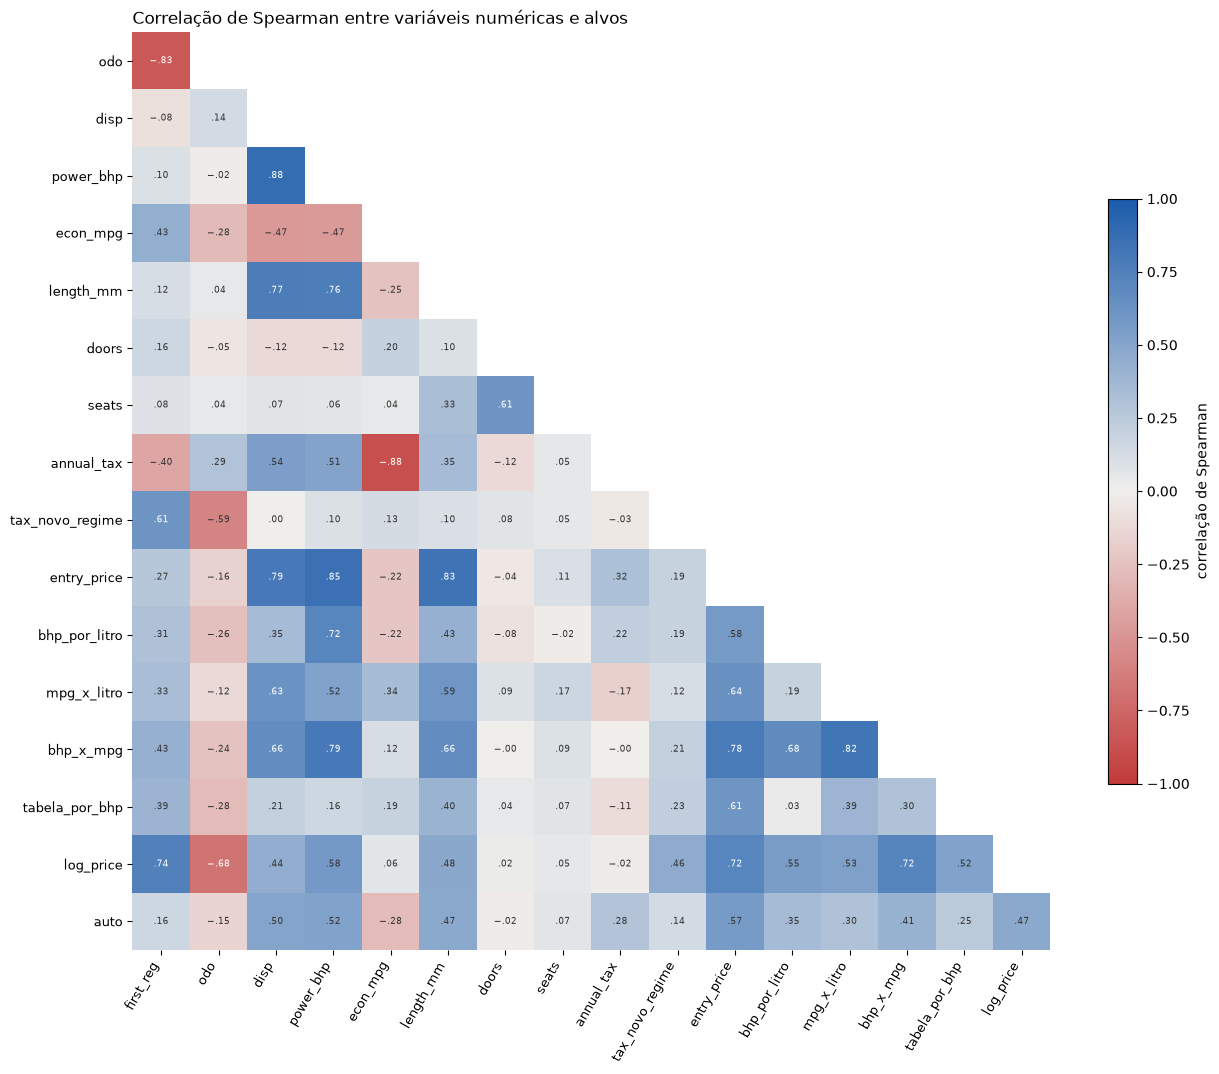

Correlação com os alvos (ordenada pela relação com o preço):


,log_price,auto
first_reg,0.74,0.16
bhp_x_mpg,0.72,0.41
entry_price,0.72,0.57
odo,-0.68,-0.15
power_bhp,0.58,0.52
bhp_por_litro,0.55,0.35
mpg_x_litro,0.53,0.30
tabela_por_bhp,0.52,0.25
length_mm,0.48,0.47
tax_novo_regime,0.46,0.14


In [46]:
from matplotlib.colors import LinearSegmentedColormap

insp = df_feat_insp.assign(log_price=np.log(df_feat_insp["price"]))
colunas_mapa = (["first_reg", "odo", "disp", "power_bhp", "econ_mpg", "length_mm", "doors", "seats",
                 "annual_tax", "tax_novo_regime", "entry_price"]
                + FEATURES_COMBINADAS + ["log_price", "auto"])
corr = insp[colunas_mapa].corr(method="spearman")
# Só o triângulo de baixo (o de cima é o espelho); sem a 1ª linha e a última coluna, que ficariam vazias
corr_metade = corr.where(np.tril(np.ones(corr.shape, dtype=bool), k=-1)).iloc[1:, :-1]

# Divergente: azul (positiva) -> cinza (zero) -> vermelho (negativa)
cmap = LinearSegmentedColormap.from_list("div", ["#c23b3a", "#f0efec", "#1c5cab"])

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_metade, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(corr_metade.shape[1]), corr_metade.columns, rotation=60, ha="right", fontsize=9)
ax.set_yticks(range(corr_metade.shape[0]), corr_metade.index, fontsize=9)
for i in range(corr_metade.shape[0]):
    for j in range(i + 1):
        v = corr_metade.iloc[i, j]
        ax.text(j, i, f"{v:.2f}".replace("0.", ".").replace("-.", "−."), ha="center", va="center",
                fontsize=6.5, color="white" if abs(v) > 0.6 else "#333333")
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_title("Correlação de Spearman entre variáveis numéricas e alvos", loc="left", fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.6, label="correlação de Spearman")
plt.tight_layout()
plt.show()

print("Correlação com os alvos (ordenada pela relação com o preço):")
corr.loc[colunas_mapa[:-2], ["log_price", "auto"]].sort_values("log_price", key=abs, ascending=False).round(2)

**Leitura:**

- **Redundâncias:** `annual_tax` × `econ_mpg` (−0,88): o imposto mede emissões, que dependem do consumo.
- **Preço:** as relações mais fortes são ano de registro (+0,74), `entry_price` e `bhp_x_mpg` (+0,72) e quilometragem (−0,68).
- **Câmbio:** `entry_price` (+0,57), potência (+0,52) e cilindrada (+0,50).
- `mpg_x_litro` tem correlação moderada com o câmbio (+0,30), mas foi a feature que, sozinha, mais ajudou o Modelo 2 na régua. Correlação e ganho real respondem a perguntas diferentes, e por isso usamos as duas.

### Resumo das features

| # | Feature | O que representa | Preço | Câmbio |
|---|---|---|---|---|
| 1 | `bhp_por_litro` | força do motor | ✓ | |
| 2 | `mpg_x_litro` | eficiência do motor | ✓ | ✓ |
| 3 | `bhp_x_mpg` | força × eficiência (tecnologia) | | ✓ |
| 4 | `tabela_por_bhp` | prêmio da marca | | ✓ |
| 5 | `entry_price` preenchido + flag | preço de tabela recuperado do mesmo modelo de carro | ✓ | |

**Como confirmamos a escolha.** Além da régua, fizemos um teste mais rigoroso (rodado à parte, sobre a base sem duplicatas):

1. **Base reservada:** antes de qualquer teste, separamos 15% dos modelos de carro (22.677 anúncios de 76 `ref_code`s inéditos) e 10% dos demais anúncios (14.292 de carros conhecidos).
2. **Retirar uma por vez:** no restante, treinamos cada modelo sem cada feature, em 30 divisões (15 aleatórias e 15 por `ref_code`). Ficou só o que piora o erro de forma consistente quando é retirado.
3. **Confirmação na base reservada:** este conjunto contra um conjunto maior de features.

| | Carro conhecido | Carro inédito |
|---|---|---|
| **Preço** | empate (+0,05%) | **−0,8%** (melhor) |
| **Câmbio** | empate (−0,2%) | **−1,0%** (melhor) |

Com menos features, o modelo fica igual nos carros conhecidos e **melhor nos inéditos**.

- **Câmbio:** as features valem a pena. Sem elas, o erro sobe **7,2%** (carro conhecido).
- **Preço:** ajudam pouco (1% a 2%). O modelo de preço depende principalmente das colunas originais.
- **Escopo de validade:** em carros inéditos o erro é muito maior (câmbio 0,37 contra 0,19; preço 0,23 contra 0,18), e nenhuma feature resolve isso.

*Cuidado:* a base reservada já foi usada nesta escolha. Daqui em diante, ela deve ser aberta só para avaliar os modelos finais.

## Parte 4

INSTRUÇÕES PARA ATUALIZAR O NOTEBOOK projeto1.ipynb

CONTEXTO
O notebook é um projeto de modelagem de carros usados (base cars.csv, Reino Unido) com dois modelos:
Modelo 1 prevê o preço (price); Modelo 2 prevê o câmbio (gearbox: Automatic/Manual) e a probabilidade de ser automático.
O notebook já tem: EDA, a seção de limpeza (função limpar()) e a seção de feature engineering (função criar_features(),
classe EstatisticasRef e a "régua com e sem": função testar()).
O estilo do notebook é: para cada questão, um markdown com a observação/hipótese, um código que testa,
e um markdown com o resultado e a decisão. Cada título fica sozinho numa célula markdown própria.
As seções principais usam "##" e tudo dentro delas usa "###". Mantenha esse estilo.

A tarefa tem duas partes:
(A) quatro correções pontuais em células que já existem;
(B) inserir a nova seção inteira (32 células) logo DEPOIS da última célula da seção de feature engineering, que é o
    markdown com a tabela de resumo (começa com "Diferença = erro com a feature − erro sem").

REGRAS
- Copie os textos e códigos EXATAMENTE como estão abaixo. Não reescreva, não resuma, não mude números.
- Cada célula está entre "===== CÉLULA N (tipo) =====" e "===== FIM DA CÉLULA N =====". Não copie essas linhas de marcação.
- Depois de aplicar tudo, rode Restart & Run All e confira as saídas com a lista "SAÍDAS ESPERADAS" no final.
  Se algum número não bater, NÃO altere os markdowns: avise qual número saiu diferente.

------------------------------------------------------------------------------------------------
(A) CORREÇÕES PONTUAIS
------------------------------------------------------------------------------------------------

A1. Markdown de abertura da limpeza (começa com "Na EDA encontramos vários problemas na base").
A última linha está incompleta. Troque a linha:
- **Não quebra se faltar coluna.**
por:
- **Não quebra se faltar coluna.** O arquivo de avaliação provavelmente não tem `price` nem `gearbox`.

A2. Markdown da régua (lista que começa com "- **Modelo:** `HistGradientBoosting`").
Na linha que começa com "- **Erro do preço:**", apague a frase final:
 Diferenças menores que ~0,002 estão dentro do ruído.

A3. Markdown "Juntando as features aprovadas" (começa com "As features são de **dois tipos**").
Há uma vírgula dupla em "as combinadas, , `tax_co2`". Deixe só uma vírgula: "as combinadas, `tax_co2`".

A4. Código da régua (célula que contém "from sklearn.ensemble import HistGradientBoostingClassifier").
No topo dessa célula existem duas linhas:
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
Troque essas duas linhas por:
import contextlib, io, warnings
from joblib.externals.loky import cpu_count

# No Windows, o joblib não consegue contar os núcleos físicos e imprime um aviso enorme.
# Fazemos essa contagem uma vez "em silêncio"; o resultado fica guardado e o aviso não volta.
with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")
    cpu_count(only_physical_cores=True)

------------------------------------------------------------------------------------------------
(B) NOVA SEÇÃO — inserir depois do markdown com a tabela de resumo da seção de feature engineering
------------------------------------------------------------------------------------------------
Variáveis que esta seção usa e que JÁ EXISTEM no notebook (criadas nas seções de limpeza e de feature engineering):
df, df_limpo, df_feat, avaliacao_fake, limpar, criar_features, aux, BASE, idx_preco, idx_cambio, testar,
KFold, HistGradientBoostingRegressor, HistGradientBoostingClassifier, root_mean_squared_error, log_loss,
FEATURES_NOVAS_PRECO, FEATURES_NOVAS_CAMBIO, FEATURES_REL_REF.

===== CÉLULA 1 (markdown) =====
## Bases e colunas de cada modelo
===== FIM DA CÉLULA 1 =====

===== CÉLULA 2 (markdown) =====
A seção de feature engineering decidiu quais features novas criar. Antes de treinar os modelos de verdade, faltam quatro passos:

1. **Remover anúncios duplicados** das bases de treino;
2. **Fechar três decisões de colunas que ficaram pendentes:** a cor (`paint`), o câmbio como feature do modelo de preço e o preço como feature do modelo de câmbio;
3. **Escrever as listas finais** de features de cada modelo;
4. **Juntar a limpeza e as features numa função só**, `preparar()`, que será usada também na FINAL — PREDICTION SECTION.

`ref_code` continua de fora por enquanto: ele tem 513 categorias, e a forma de usá-lo depende do tipo de modelo, o que será decidido na modelagem.
===== FIM DA CÉLULA 2 =====

===== CÉLULA 3 (markdown) =====
### Anúncios duplicados
===== FIM DA CÉLULA 3 =====

===== CÉLULA 4 (markdown) =====
**O que vimos na EDA:** há anúncios idênticos em todas as colunas, exceto o `id`.

**Por que isso importa:** se uma cópia cair no treino e a outra na validação, o modelo "acerta" a validação porque já viu aquele anúncio. O erro medido fica otimista, e o desempenho real em dados novos seria pior do que reportaríamos.

**Perguntas:** quantos são? E são o mesmo carro anunciado mais de uma vez, ou carros diferentes?
===== FIM DA CÉLULA 4 =====

===== CÉLULA 5 (código) =====
colunas_sem_id = [c for c in df_limpo.columns if c != "id"]
duplicada = df_limpo.duplicated(subset=colunas_sem_id, keep=False)

print("linhas que têm pelo menos uma cópia idêntica (fora o id):", duplicada.sum())
print("cópias a remover (mantendo uma de cada):", df_limpo.duplicated(subset=colunas_sem_id).sum())

# Quantas cópias tem cada grupo de anúncios repetidos?
# keep=False marca TODAS as linhas de um grupo; dropna=False não deixa sumir linhas com NaN
tamanho_grupo = df_limpo[duplicada].groupby(colunas_sem_id, dropna=False).size()
print("\nanúncios por grupo de cópias:", tamanho_grupo.value_counts().sort_index().to_dict())

# Os grupos grandes (5 ou mais anúncios iguais): que carros são?
grandes = tamanho_grupo[tamanho_grupo >= 5].reset_index()
print("quilometragem dos grupos com 5+ cópias:", sorted(grandes["odo"].tolist()))

# Exemplo de um grupo de cópias
exemplo = df_limpo[duplicada].sort_values(colunas_sem_id).head(2)
exemplo[["id", "maker", "ref_code", "first_reg", "listed_yr", "listed_mo", "odo", "paint", "price"]]
===== FIM DA CÉLULA 5 =====

===== CÉLULA 6 (markdown) =====
**Resultado:** 8.984 linhas têm pelo menos uma cópia, o que dá **4.551 cópias excedentes** (2,7% da base). Há dois tipos de repetição:

- **Pares (4.367 grupos), a grande maioria.** Parecem o mesmo carro anunciado duas vezes, como no exemplo: dois Jaguar com exatamente 1.722 milhas, mesma cor e mesmo preço.
- **Alguns grupos grandes**, um deles com 20 anúncios idênticos. Todos os grupos com 5 ou mais cópias são de carros **zero** (de 1 a 101 milhas): provavelmente estoque de concessionária, com vários carros iguais anunciados do mesmo jeito.

**Decisão:** remover as cópias, mantendo uma de cada grupo, **só nas bases de treino**. Seja o mesmo carro repetido ou vários carros idênticos, linhas iguais não trazem informação nova, e deixá-las faria a validação parecer melhor do que é. Na previsão final, todo anúncio recebe previsão, mesmo que seja repetido.

*Limitação registrada:* a régua da seção de feature engineering rodou antes desta remoção. Como as cópias são só 2,7% da base e afetam igualmente os lados "com" e "sem" de cada comparação, o efeito nas decisões deve ser pequeno.

Depois da remoção, montamos a base de cada modelo: o Modelo 1 usa só anúncios com preço conhecido, e o Modelo 2 só anúncios com câmbio conhecido.
===== FIM DA CÉLULA 6 =====

===== CÉLULA 7 (código) =====
df_treino = df_feat.drop_duplicates(subset=colunas_sem_id).reset_index(drop=True)

base_preco = df_treino[df_treino["price"].notna()].reset_index(drop=True)
base_cambio = df_treino[df_treino["auto"].notna()].reset_index(drop=True)

print("base completa:", df_feat.shape, "-> sem duplicatas:", df_treino.shape)
print("base do Modelo 1 (preço):", base_preco.shape)
print("base do Modelo 2 (câmbio):", base_cambio.shape,
      "| % automático:", round(base_cambio["auto"].mean() * 100, 1))
===== FIM DA CÉLULA 7 =====

===== CÉLULA 8 (markdown) =====
**Resultado:** ficam 165.599 anúncios sem duplicatas: 164.727 com preço (Modelo 1) e 165.485 com câmbio (Modelo 2). Destes, 36,0% são automáticos, a mesma proporção da base original, então a remoção não mudou o equilíbrio entre as classes.
===== FIM DA CÉLULA 8 =====

===== CÉLULA 9 (markdown) =====
### Decisão pendente 1 — A cor (`paint`)
===== FIM DA CÉLULA 9 =====

===== CÉLULA 10 (markdown) =====
**O que vimos:** a cor ficou fora da régua da seção de feature engineering sem ser testada. A intuição é que ela influencia pouco: o preço de um carro depende muito mais do modelo, da idade e da quilometragem. Mas intuição não é teste.

**Teste:** a mesma régua "com e sem" da seção de feature engineering.
===== FIM DA CÉLULA 10 =====

===== CÉLULA 11 (código) =====
# A cor precisa virar "category" para o HistGradientBoosting tratá-la como categórica,
# do mesmo jeito que maker, fuel e body na régua
aux["paint"] = aux["paint"].astype("category")
testar(["paint"])
===== FIM DA CÉLULA 11 =====

===== CÉLULA 12 (markdown) =====
**Resultado:** a cor **piora** os dois modelos, em todas as divisões: +0,0008 no preço e +0,0020 no câmbio. Com 14 cores (e 11% de faltantes), o modelo encontra padrões que não se repetem fora do treino.

**Decisão: `paint` fica fora dos dois modelos.**
===== FIM DA CÉLULA 12 =====

===== CÉLULA 13 (markdown) =====
### Decisão pendente 2 — O câmbio no modelo de preço
===== FIM DA CÉLULA 13 =====

===== CÉLULA 14 (markdown) =====
**O que sabemos:** o vendedor informa o câmbio no formulário, e automáticos costumam ser mais caros. Faz sentido o modelo de preço usar o câmbio.

**O risco:** o enunciado não diz quais colunas vêm no arquivo de avaliação. Se ele vier **sem** o câmbio, um modelo que aprendeu a depender dele pode errar mais do que um modelo que nunca o usou.

**Teste em três cenários**, com as mesmas amostras e divisões da régua, só no modelo de preço:
1. sem o câmbio;
2. com o câmbio;
3. treinado com o câmbio, mas avaliado com o câmbio apagado (simula um arquivo de avaliação sem a coluna).

A função `testar()` não serve aqui, porque ela acrescenta a feature nos dois modelos ao mesmo tempo, e o câmbio é o alvo do Modelo 2. Por isso escrevemos uma versão para um modelo só. Ela usa o mesmo modelo, as mesmas amostras e as mesmas divisões da régua, então o erro "sem o câmbio" sai igual ao "erro_sem" da régua (0,1944).
===== FIM DA CÉLULA 14 =====

===== CÉLULA 15 (código) =====
def erros_um_modelo(alvo, idx, colunas, apagar_na_validacao=None):
    """Erro em cada uma das 4 divisões da régua, para UM modelo.

    apagar_na_validacao: coluna que é trocada por NaN só na validação,
    para simular um arquivo de avaliação que não traz essa informação.
    """
    d = aux.loc[idx]
    erros = []
    for i_tr, i_va in KFold(4, shuffle=True, random_state=0).split(d):
        tr, va = d.iloc[i_tr], d.iloc[i_va].copy()
        if apagar_na_validacao is not None:
            va[apagar_na_validacao] = np.nan
        if alvo == "log_price":
            m = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(root_mean_squared_error(va[alvo], m.predict(va[colunas])))
        else:
            m = HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(log_loss(va[alvo], m.predict_proba(va[colunas])[:, 1]))
    return np.array(erros)


sem_cambio = erros_um_modelo("log_price", idx_preco, BASE)
com_cambio = erros_um_modelo("log_price", idx_preco, BASE + ["auto"])
com_cambio_sumido = erros_um_modelo("log_price", idx_preco, BASE + ["auto"], apagar_na_validacao="auto")

pd.DataFrame({
    "erro médio": [sem_cambio.mean(), com_cambio.mean(), com_cambio_sumido.mean()],
    "divisões melhores que 'sem'": ["-", f"{(com_cambio < sem_cambio).sum()}/4", f"{(com_cambio_sumido < sem_cambio).sum()}/4"],
}, index=["sem o câmbio", "com o câmbio", "treinado com o câmbio, avaliado sem ele"]).round(4)
===== FIM DA CÉLULA 15 =====

===== CÉLULA 16 (markdown) =====
**Resultado:**

- **Com o câmbio**, o erro cai de 0,1944 para **0,1927** (−0,0017, nas 4 divisões). É um ganho real.
- **Mas se o câmbio sumir na avaliação**, o erro sobe para **0,2024**: 4% **pior** do que se nunca tivéssemos usado o câmbio. O modelo aprendeu a confiar nessa coluna e se perde sem ela.

**Próxima pergunta:** se o câmbio faltar, dá para preenchê-lo com a previsão do Modelo 2? O formulário vai ter esse modelo de qualquer jeito.

**Teste:** em cada divisão, um modelo de câmbio treinado **só no treino** preenche o câmbio da validação com a sua previsão (automático se a probabilidade for pelo menos 50%). O modelo de preço, treinado com o câmbio real, é avaliado com esse câmbio previsto.
===== FIM DA CÉLULA 16 =====

===== CÉLULA 17 (código) =====
# E se o arquivo de avaliação vier sem o câmbio? O formulário já tem um modelo para isso: o Modelo 2.
# Teste: em cada divisão, um modelo de câmbio treinado SÓ no treino preenche o câmbio da validação.
d = aux.loc[idx_preco]
erros_previsto = []
for i_tr, i_va in KFold(4, shuffle=True, random_state=0).split(d):
    tr, va = d.iloc[i_tr], d.iloc[i_va].copy()

    # alguns anúncios de treino não têm câmbio, e um classificador não treina com alvo vazio
    tr_cambio = tr[tr["auto"].notna()]
    m_cambio = HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype")
    m_cambio.fit(tr_cambio[BASE], tr_cambio["auto"])
    va["auto"] = (m_cambio.predict_proba(va[BASE])[:, 1] >= 0.5).astype(float)  # câmbio previsto, não o real

    m_preco = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype")
    m_preco.fit(tr[BASE + ["auto"]], tr["log_price"])
    erros_previsto.append(root_mean_squared_error(va["log_price"], m_preco.predict(va[BASE + ["auto"]])))
erros_previsto = np.array(erros_previsto)

print(f"treinado com o câmbio, avaliado com o câmbio PREVISTO pelo Modelo 2: {erros_previsto.mean():.4f}"
      f" | divisões melhores que 'sem o câmbio': {(erros_previsto < sem_cambio).sum()}/4")
===== FIM DA CÉLULA 17 =====

===== CÉLULA 18 (markdown) =====
**Resultado:** não compensa. Com o câmbio previsto, o erro fica em **0,1951**, um pouco **pior** que o do modelo sem câmbio (0,1944), melhorando em só 1 de 4 divisões. O Modelo 2 erra o câmbio em parte dos anúncios, e esses erros passam para o preço.

**Decisão: treinar duas versões do Modelo 1.**

- **Versão principal, com o câmbio:** usada nos anúncios que informam o câmbio (erro 0,1927).
- **Versão reserva, sem o câmbio:** usada nos anúncios sem câmbio, ou em todos, se o arquivo de avaliação vier sem essa coluna (erro 0,1944, em vez de 0,2024).

Assim, cada anúncio recebe a melhor versão possível para a informação que tem. O custo é treinar um modelo a mais, o que é barato.
===== FIM DA CÉLULA 18 =====

===== CÉLULA 19 (markdown) =====
### Decisão pendente 3 — O preço no modelo de câmbio
===== FIM DA CÉLULA 19 =====

===== CÉLULA 20 (markdown) =====
**O que decidimos antes:** o Modelo 2 não usa o preço, por dois motivos:

1. O formulário *sugere* o preço (é o Modelo 1). No momento em que o câmbio é inferido, o preço pode ainda não ter sido digitado.
2. O Modelo 1 usa o câmbio. Se o Modelo 2 usasse o preço, um dependeria do outro em círculo.

**O que falta:** medir quanto essa decisão custa, para justificá-la com números.
===== FIM DA CÉLULA 20 =====

===== CÉLULA 21 (código) =====
sem_preco = erros_um_modelo("auto", idx_cambio, BASE)
com_preco = erros_um_modelo("auto", idx_cambio, BASE + ["log_price"])

pd.DataFrame({
    "erro médio (log loss)": [sem_preco.mean(), com_preco.mean()],
    "divisões melhores que 'sem'": ["-", f"{(com_preco < sem_preco).sum()}/4"],
}, index=["sem o preço", "com o preço"]).round(4)
===== FIM DA CÉLULA 21 =====

===== CÉLULA 22 (markdown) =====
**Resultado:** o preço ajudaria bastante: o erro cairia de 0,2404 para **0,2336** (−0,0068, ou 2,8%), nas 4 divisões. Faz sentido, já que carros caros tendem a ser automáticos.

**Decisão: o preço continua fora do Modelo 2.** O ganho é real, mas depende de uma informação que não temos garantia de existir quando o câmbio é inferido, e criaria a dependência circular entre os dois modelos. Registramos o custo: **abrimos mão de cerca de 3% de erro no câmbio** em troca de um modelo que funciona com o anúncio ainda incompleto. Isso entra no escopo de validade.
===== FIM DA CÉLULA 22 =====

===== CÉLULA 23 (markdown) =====
### Listas finais de features
===== FIM DA CÉLULA 23 =====

===== CÉLULA 24 (markdown) =====
Com as pendências fechadas, montamos as listas de cada modelo. **A regra continua a mesma:** só entra informação que existe no formulário no momento em que o anúncio é criado.

- **Colunas originais (já limpas):** as mesmas 16 da régua, nos dois modelos. Ficam de fora `id` (identificador), `pct_of_list` (vazamento), `paint` (piorou na régua) e, por enquanto, `ref_code`.
- **Modelo 1 (preço):** originais + câmbio + features aprovadas para o preço na seção de feature engineering, e uma versão reserva sem o câmbio.
- **Modelo 2 (câmbio):** originais + features aprovadas para o câmbio na seção de feature engineering.
- **Condicionais** (`*_rel`): ficam numa lista separada e serão decididas na modelagem.

As listas terminam com **travas** (`assert`): se alguém alterar as listas e incluir uma coluna proibida por engano, o notebook para com erro.
===== FIM DA CÉLULA 24 =====

===== CÉLULA 25 (código) =====
# Colunas originais (já limpas) que os dois modelos recebem — as mesmas da régua
NUMERICAS_ORIGINAIS = ["first_reg", "listed_yr", "listed_mo", "odo", "disp", "power_bhp", "econ_mpg",
                       "length_mm", "doors", "seats", "annual_tax", "tax_novo_regime", "entry_price"]
CATEGORICAS = ["maker", "fuel", "body"]

# Modelo 1 (preço): originais + câmbio + features aprovadas na seção de feature engineering
FEATURES_PRECO = CATEGORICAS + NUMERICAS_ORIGINAIS + ["auto"] + FEATURES_NOVAS_PRECO
# Versão reserva do Modelo 1, para anúncios sem câmbio informado
FEATURES_PRECO_SEM_CAMBIO = [c for c in FEATURES_PRECO if c != "auto"]

# Modelo 2 (câmbio): originais + features aprovadas na seção de feature engineering (sem o preço)
FEATURES_CAMBIO = CATEGORICAS + NUMERICAS_ORIGINAIS + FEATURES_NOVAS_CAMBIO

ALVO_PRECO = "price"   # na modelagem vamos prever log(price)
ALVO_CAMBIO = "auto"   # 1 = Automatic, 0 = Manual

# Travas contra vazamento: se alguém mudar as listas sem querer, o notebook para aqui
# (o & entre dois conjuntos devolve os elementos em comum; se não for vazio, há coluna proibida)
proibidas_nos_dois = {"id", "pct_of_list", "price", "log_price", "gearbox"}
assert not proibidas_nos_dois & set(FEATURES_PRECO + FEATURES_CAMBIO)
assert "auto" not in FEATURES_CAMBIO, "o alvo do Modelo 2 não pode ser feature dele"
assert "paint" not in FEATURES_PRECO + FEATURES_CAMBIO
assert len(set(FEATURES_PRECO)) == len(FEATURES_PRECO) and len(set(FEATURES_CAMBIO)) == len(FEATURES_CAMBIO)

print(f"Modelo 1 (preço): {len(FEATURES_PRECO)} features | versão sem câmbio: {len(FEATURES_PRECO_SEM_CAMBIO)}")
print(f"Modelo 2 (câmbio): {len(FEATURES_CAMBIO)} features")
print("\nsó no preço:", sorted(set(FEATURES_PRECO) - set(FEATURES_CAMBIO)))
print("só no câmbio:", sorted(set(FEATURES_CAMBIO) - set(FEATURES_PRECO)))
print("condicionais (decididas na modelagem):", FEATURES_REL_REF)
===== FIM DA CÉLULA 25 =====

===== CÉLULA 26 (markdown) =====
**Resultado:** 24 features no Modelo 1 (23 na versão sem câmbio) e 25 no Modelo 2. A diferença entre os dois é exatamente o que decidimos: o câmbio só no preço; `tax_co2` e `n_specs_faltantes` só no câmbio.
===== FIM DA CÉLULA 26 =====

===== CÉLULA 27 (markdown) =====
### O pipeline: a função `preparar()`
===== FIM DA CÉLULA 27 =====

===== CÉLULA 28 (markdown) =====
Até aqui, a base passou por duas funções em sequência: `limpar()` e `criar_features()`. Juntamos as duas numa função só, `preparar()`. Na FINAL — PREDICTION SECTION, o arquivo de avaliação vai passar **exatamente** por ela, o que garante que treino e avaliação recebam o mesmo tratamento.

A classe `EstatisticasRef` (preenchimento do `entry_price` e features relativas) fica de fora **de propósito**: ela aprende com os dados, então precisa de um `fit` no treino antes de ser aplicada. Isso acontece na modelagem.

**Duas verificações:**

1. `preparar()` dá exatamente o mesmo resultado que os passos separados que usamos até aqui;
2. o arquivo de avaliação simulado na seção de limpeza (sem alvos, com um carro inédito, um combustível novo e uma coluna vazia) passa pelo pipeline sem erro, e as features das listas existem no resultado, exceto `entry_price_imputado`, que só é criada pela `EstatisticasRef`.
===== FIM DA CÉLULA 28 =====

===== CÉLULA 29 (código) =====
def preparar(df_bruto):
    """Pipeline determinístico: arquivo cru -> colunas limpas + features linha a linha.

    É a MESMA função para a base de treino e para o arquivo da FINAL — PREDICTION SECTION.
    As features que aprendem com os dados (EstatisticasRef) ficam de fora de propósito:
    elas precisam de um fit no treino e são aplicadas depois, na modelagem.
    """
    return criar_features(limpar(df_bruto))


# Verificação 1: preparar() dá exatamente o mesmo resultado que os passos separados
# (assert_frame_equal compara valor por valor, tipos e ordem das colunas; para com erro se houver diferença)
pd.testing.assert_frame_equal(preparar(df), df_feat)

# Verificação 2: o arquivo de avaliação simulado passa pelo pipeline inteiro
teste = preparar(avaliacao_fake)
faltando = sorted(c for c in set(FEATURES_PRECO + FEATURES_CAMBIO) if c not in teste.columns)

print("linhas:", len(avaliacao_fake), "->", len(teste))
print("features das listas que ainda não existem:", faltando)
assert faltando == ["entry_price_imputado"], "só a flag do EstatisticasRef pode faltar aqui"
===== FIM DA CÉLULA 29 =====

===== CÉLULA 30 (markdown) =====
**Resultado:** as duas verificações passaram. O pipeline está pronto para ser reaproveitado na seção final.
===== FIM DA CÉLULA 30 =====

===== CÉLULA 31 (markdown) =====
### Resumo das decisões de bases e colunas
===== FIM DA CÉLULA 31 =====

===== CÉLULA 32 (markdown) =====
| Decisão | Evidência |
|---|---|
| Remover 4.551 cópias, só das bases de treino | 2,7% da base: pares de reanúncios e estoque de carros zero |
| `paint` fora dos dois modelos | Piorou o preço (+0,0008) e o câmbio (+0,0020), em 0 de 4 divisões |
| Câmbio no Modelo 1, com uma versão reserva sem câmbio | Com: −0,0017 (4/4). Se sumir na avaliação: 4% pior. Preencher com o Modelo 2 não compensa |
| Preço fora do Modelo 2 | Ajudaria −0,0068 (2,8%), mas não é garantido no formulário e criaria dependência circular |
| `preparar()` = `limpar()` + `criar_features()` | Mesmo resultado dos passos separados; aguenta o arquivo simulado |

**Próximo passo:** definir a estratégia de validação com a base completa e calcular as baselines, os pontos de partida que qualquer modelo precisa superar.
===== FIM DA CÉLULA 32 =====

------------------------------------------------------------------------------------------------
SAÍDAS ESPERADAS (depois de Restart & Run All)
------------------------------------------------------------------------------------------------
Célula 5:  8984 linhas com cópia; 4551 cópias a remover;
           grupos {2: 4367, 3: 45, 4: 8, 5: 9, 6: 3, 20: 1};
           quilometragem dos grupos 5+: [1.0, 5.0, 6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 14.0, 20.0, 100.0, 100.0, 101.0];
           exemplo: dois Jaguar M1003, 2018, odo 1722, Grey, price 46306.
Célula 7:  base completa (170150, 32) -> sem duplicatas (165599, 32);
           Modelo 1 (164727, 32); Modelo 2 (165485, 32), 36.0% automático.
Célula 11: preço  erro_sem 0.1944, erro_com 0.1952, diferença 0.0008, 0/4;
           câmbio erro_sem 0.2404, erro_com 0.2424, diferença 0.0020, 0/4.
Célula 15: sem o câmbio 0.1944; com o câmbio 0.1927 (4/4); treinado com, avaliado sem 0.2024 (0/4).
Célula 17: 0.1951 | 1/4.
Célula 21: sem o preço 0.2404; com o preço 0.2336 (4/4).
Célula 25: Modelo 1: 24 features | versão sem câmbio: 23; Modelo 2: 25 features;
           só no preço: ['auto']; só no câmbio: ['n_specs_faltantes', 'tax_co2'];
           condicionais: ['power_bhp_rel', 'econ_mpg_rel', 'disp_rel'].
Célula 29: linhas 300 -> 300; features que ainda não existem: ['entry_price_imputado'].
A seção leva cerca de 40 segundos para rodar.

## Parte 5: MODELOS 


## Modelo 1 — Preço

### Divisão treino / validação / teste

**Como dividimos:** o enunciado diz que o conjunto de avaliação tem composição diferente da nossa base. Por isso, tanto a validação quanto o teste têm duas partes:

- **"conhecido":** anúncios sorteados, de modelos de carro (`ref_code`) que também aparecem no treino;
- **"inédito":** `ref_code`s inteiros que ficam fora do treino. Simula carros que o modelo nunca viu.

**Cuidados contra vazamento:**
1. As duplicatas são removidas **antes** de dividir. Assim, uma cópia não cai no treino e a outra na validação.
2. A régua de features usou as amostras `idx_preco` e `idx_cambio`. O teste "conhecido" sai **só de anúncios fora dessas amostras**, que nunca influenciaram nenhuma decisão.
3. A `EstatisticasRef` (preenchimento do `entry_price`) aprende **só com o treino**.
4. O teste não é usado nesta seção. Ele será usado **uma única vez**, no modelo final.

*Limitação:* os `ref_code`s do teste "inédito" tiveram outros anúncios dentro da amostra da régua, então esse teste não é 100% virgem em relação à escolha de features.

In [49]:
# divisao 
from sklearn.model_selection import GroupShuffleSplit

# 1) Duplicatas fora ANTES de dividir (o índice original é mantido, sem reset_index)
colunas_sem_id = [c for c in df_feat.columns if c != "id"]
df_sem_dup = df_feat.drop_duplicates(subset=colunas_sem_id)
base_preco = df_sem_dup[df_sem_dup["price"].notna()]

# Anúncios que a régua de features já usou
usadas_na_regua = set(idx_preco) | set(idx_cambio)


def separar(d, frac_grupos, n_conhecido, semente):
    """Tira de d duas partes:
    - 'inédito': ref_codes inteiros (fração frac_grupos dos ref_codes)
    - 'conhecido': n_conhecido anúncios sorteados entre os que a régua NÃO usou
    Devolve (resto, conhecido, inédito)."""
    gss = GroupShuffleSplit(n_splits=1, test_size=frac_grupos, random_state=semente)
    i_resto, i_inedito = next(gss.split(d, groups=d["ref_code"]))
    resto, inedito = d.iloc[i_resto], d.iloc[i_inedito]

    candidatos = resto[~resto.index.isin(usadas_na_regua)]
    conhecido = candidatos.sample(n=n_conhecido, random_state=semente)
    resto = resto.drop(conhecido.index)
    return resto, conhecido, inedito


# Teste primeiro (fica guardado até o final), depois a validação
dev, teste_conhecido, teste_inedito = separar(base_preco, 0.10, 15_000, semente=42)
treino, val_conhecido, val_inedito = separar(dev, 0.10, 15_000, semente=7)

# Trava: nenhum ref_code "inédito" pode aparecer no treino
assert not set(val_inedito["ref_code"]) & set(treino["ref_code"])
assert not set(teste_inedito["ref_code"]) & set(dev["ref_code"])

for nome, parte in [("treino", treino), ("val conhecido", val_conhecido), ("val inédito", val_inedito),
                    ("teste conhecido", teste_conhecido), ("teste inédito", teste_inedito)]:
    print(f"{nome:16s} {len(parte):7d} anúncios | {parte['ref_code'].nunique():3d} ref_codes")

treino             99322 anúncios | 401 ref_codes
val conhecido      15000 anúncios | 365 ref_codes
val inédito        19776 anúncios |  46 ref_codes
teste conhecido    15000 anúncios | 399 ref_codes
teste inédito      15629 anúncios |  52 ref_codes


In [50]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

# Colunas do Modelo 1 (decididas na seção de feature engineering)
NUMERICAS_ORIGINAIS = ["first_reg", "listed_yr", "listed_mo", "odo", "disp", "power_bhp", "econ_mpg",
                       "length_mm", "doors", "seats", "annual_tax", "tax_novo_regime", "entry_price"]
CATEGORICAS = ["maker", "fuel", "body"]
FEATURES_PRECO = CATEGORICAS + NUMERICAS_ORIGINAIS + ["auto"] + FEATURES_NOVAS_PRECO
NUMERICAS_PRECO = [c for c in FEATURES_PRECO if c not in CATEGORICAS]

assert not {"id", "pct_of_list", "price", "gearbox"} & set(FEATURES_PRECO), "coluna proibida nas features"

# EstatisticasRef aprende a tabela de entry_price SÓ no treino
est_preco = EstatisticasRef().fit(treino)


def X_y(d):
    """Aplica a EstatisticasRef (já ajustada no treino) e separa X e y = log(price)."""
    d = est_preco.transform(d)
    return d[FEATURES_PRECO], np.log(d["price"])


X_tr, y_tr = X_y(treino)
X_vc, y_vc = X_y(val_conhecido)
X_vi, y_vi = X_y(val_inedito)


# --- Pré-processamento (fica DENTRO do Pipeline, então só aprende com o treino) ---

# Lineares (Ridge/Lasso): não aceitam NaN e penalizam coeficientes, então precisam de
# imputação + escala + one-hot. Log nas numéricas muito assimétricas, como no log10 do projeto anterior.
NUM_LOG = ["odo", "entry_price", "power_bhp"]
NUM_SEM_LOG = [c for c in NUMERICAS_PRECO if c not in NUM_LOG]

def preproc_linear():
    return ColumnTransformer([
        ("num_log", Pipeline([("log", FunctionTransformer(np.log1p)),
                              ("imp", SimpleImputer(strategy="median", add_indicator=True)),
                              ("esc", StandardScaler())]), NUM_LOG),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("esc", StandardScaler())]), NUM_SEM_LOG),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="desconhecido")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAS),
    ])

# Árvore e Random Forest: não precisam de escala; categorias viram números (0, 1, 2...)
def preproc_arvore():
    return ColumnTransformer([
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="desconhecido")),
                          ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]),
         CATEGORICAS),
        ("num", SimpleImputer(strategy="median", add_indicator=True), NUMERICAS_PRECO),
    ])

# HistGradientBoosting: aceita NaN sozinho; as categóricas só precisam virar códigos.
# Categoria nunca vista (ex.: marca nova) vira NaN em vez de dar erro.
def preproc_hgb():
    return ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CATEGORICAS),
    ], remainder="passthrough")   # as categóricas ficam nas 3 primeiras colunas


# --- Avaliação ---
def metricas(modelo, X, y_log):
    """RMSE em log(price) + MAE em libras + MAPE em %."""
    p_log = modelo.predict(X)
    real, prev = np.exp(y_log), np.exp(p_log)
    return (root_mean_squared_error(y_log, p_log),
            mean_absolute_error(real, prev),
            mean_absolute_percentage_error(real, prev) * 100)


def treinar_e_validar(modelo, nome, config):
    """Treina no treino e mede no treino (para ver overfitting) e nas duas validações."""
    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    tempo = time.perf_counter() - t0

    rmse_tr, _, _ = metricas(modelo, X_tr, y_tr)
    rmse_c, mae_c, mape_c = metricas(modelo, X_vc, y_vc)
    rmse_i, mae_i, mape_i = metricas(modelo, X_vi, y_vi)
    return {"modelo": nome, "config": config,
            "RMSE_log treino": rmse_tr,
            "RMSE_log conhecido": rmse_c, "RMSE_log inédito": rmse_i,
            "RMSE_log médio": (rmse_c + rmse_i) / 2,
            "MAPE% conhecido": mape_c, "MAPE% inédito": mape_i,
            "MAE £ conhecido": mae_c, "MAE £ inédito": mae_i,
            "tempo (s)": tempo}

In [52]:
#baseline - tudo e melhor mas coloquei para ter 

from sklearn.dummy import DummyRegressor

# Ponto de partida: prever sempre a mediana do log(price) do treino. Qualquer modelo precisa superar isso.
res_base = pd.DataFrame([treinar_e_validar(DummyRegressor(strategy="median"), "Baseline (mediana)", "-")])
res_base.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Baseline (mediana),-,1.019,1.022,0.972,0.997,137.997,131.051,9685.134,8588.595,0.003


**Resultado:** prever sempre a mediana dá um RMSE em log de **≈ 1,0** (MAPE de 131–138%, erro médio de ~£9 mil). Esse é o ponto de partida: qualquer modelo que não fique bem abaixo disso não aprendeu nada útil.

In [54]:
#ridge   
from sklearn.linear_model import Lasso, Ridge

linhas = []
for alpha in [0.01, 0.1, 1, 10, 100, 1000]:
    pipe = Pipeline([("prep", preproc_linear()), ("modelo", Ridge(alpha=alpha))])
    linhas.append(treinar_e_validar(pipe, "Ridge", f"alpha={alpha}"))

res_ridge = pd.DataFrame(linhas)
res_ridge.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Ridge,alpha=0.01,0.288,0.292,0.290,0.291,21.528,21.809,2666.572,3060.692,1.752
1,Ridge,alpha=0.1,0.288,0.292,0.289,0.290,21.530,21.733,2667.225,3024.137,1.589
2,Ridge,alpha=1,0.288,0.292,0.290,0.291,21.532,21.795,2666.585,3028.871,1.414
3,Ridge,alpha=10,0.289,0.292,0.291,0.291,21.571,21.816,2667.270,2914.969,1.291
4,Ridge,alpha=100,0.292,0.294,0.295,0.295,21.777,21.711,2699.300,2778.814,0.823
5,Ridge,alpha=1000,0.301,0.302,0.301,0.302,22.380,21.946,2731.200,2892.660,0.619


**Resultado:** o Ridge fica praticamente igual em toda a faixa de alpha de 0,01 a 10 (RMSE em log ≈ 0,290–0,291) e só piora com regularização forte (0,302 com alpha = 1000). O melhor valor é **alpha = 0,1** (RMSE médio 0,290, MAPE ~21,5%).

**Por que a regularização quase não muda nada:** são ~99 mil anúncios para poucas dezenas de colunas. O modelo linear não está sofrendo de overfitting (treino 0,288 e validação 0,292 são quase iguais), então não sobra o que a penalização "consertar".

**Ponto interessante:** o erro em carros inéditos (0,289) é igual ao de carros conhecidos (0,292). O modelo linear não "decora" modelos de carro específicos, então não perde nada quando vê um carro novo. Por outro lado, ele é limitado: erra ~22% em média.

In [56]:
# lasso 
# Com o alvo em log, alphas a partir de ~0,1 já zeram quase tudo (como no projeto anterior),
# então a faixa testada é mais baixa que a do Ridge
linhas = []
for alpha in [0.00001, 0.0001, 0.001, 0.01, 0.1]:
    pipe = Pipeline([("prep", preproc_linear()), ("modelo", Lasso(alpha=alpha, max_iter=5000))])
    linhas.append(treinar_e_validar(pipe, "Lasso", f"alpha={alpha}"))

res_lasso = pd.DataFrame(linhas)
res_lasso.round(3)

c:\Users\belag\OneDrive\Documents\6 semestre\INSPER AI\Projeto 1\projeto1\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.196141e+02, tolerance: 1.022e+01
  model = cd_fast.sparse_enet_coordinate_descent(


,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Lasso,alpha=1e-05,0.288,0.292,0.289,0.290,21.516,21.768,2662.392,3008.996,61.298
1,Lasso,alpha=0.0001,0.290,0.292,0.289,0.291,21.627,21.286,2674.974,2624.906,18.917
2,Lasso,alpha=0.001,0.301,0.303,0.310,0.306,22.352,22.391,2758.285,2921.964,1.250
3,Lasso,alpha=0.01,0.328,0.331,0.328,0.329,24.410,23.959,2969.058,3360.331,0.695
4,Lasso,alpha=0.1,0.390,0.392,0.378,0.385,30.024,26.701,3715.153,3760.769,0.586


**Resultado:** o melhor Lasso (**alpha = 0,00001**, RMSE médio 0,290) empata com o Ridge. A partir de alpha = 0,001 ele começa a zerar coeficientes úteis e piora (0,385 com alpha = 0,1).

Um alpha tão pequeno quase não penaliza nada, então o melhor Lasso é praticamente uma regressão linear comum. Isso confirma o que o Ridge já mostrou: aqui não há overfitting para a regularização corrigir. O aviso de convergência (`ConvergenceWarning`) aparece porque, com alpha muito pequeno, o algoritmo precisa de muitas iterações (61 segundos). Ele não muda a conclusão.

**Conclusão sobre os modelos lineares:** o limite deles não é a regularização, é o formato. O preço depende de combinações não lineares (marca × idade × quilometragem), e uma soma ponderada de colunas não captura isso.

In [57]:
# decision tree
from sklearn.tree import DecisionTreeRegressor

linhas = []
for depth in [4, 8, 12, 16, 20, None]:
    pipe = Pipeline([("prep", preproc_arvore()),
                     ("modelo", DecisionTreeRegressor(max_depth=depth, random_state=42))])
    linhas.append(treinar_e_validar(pipe, "Decision Tree", f"max_depth={depth}"))

res_arvore = pd.DataFrame(linhas)
res_arvore.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Decision Tree,max_depth=4,0.441,0.437,0.434,0.435,35.342,34.367,4564.458,4314.222,0.703
1,Decision Tree,max_depth=8,0.288,0.292,0.345,0.318,21.969,26.498,2582.228,3659.059,0.783
2,Decision Tree,max_depth=12,0.200,0.232,0.342,0.287,16.663,26.670,1907.221,3827.639,1.097
3,Decision Tree,max_depth=16,0.131,0.224,0.365,0.295,15.173,27.885,1688.476,4015.966,1.181
4,Decision Tree,max_depth=20,0.076,0.235,0.389,0.312,15.538,29.460,1671.257,4111.616,1.931
5,Decision Tree,max_depth=None,0.010,0.246,0.397,0.321,16.320,30.009,1751.486,4173.978,2.239


**Resultado:** o padrão clássico de viés e variância aparece com clareza:

- **max_depth = 4:** underfitting. Erra mais que os lineares (0,437).
- **max_depth = 12:** melhor média (0,287), praticamente empatada com os lineares.
- **max_depth = None:** overfitting. RMSE de **0,010 no treino** (a árvore decorou cada anúncio) contra 0,246 na validação.

**O achado mais importante:** carros conhecidos e inéditos vão em **direções opostas**. Em carros conhecidos, o erro melhora até a profundidade 16 (0,224). Em carros inéditos, ele piora a partir da profundidade 8 (de 0,345 para 0,397). Quanto mais funda a árvore, mais ela aprende regras específicas de cada modelo de carro, e essas regras não servem para um carro que ela nunca viu.

Por isso o critério de escolha é a **média** dos dois: escolher só pelo "conhecido" levaria a uma árvore funda que falharia nos carros novos da avaliação. A árvore escolhida (max_depth = 12) é **pior que o Ridge em carros inéditos** (0,342 contra 0,289).

In [58]:
# random forest 
from sklearn.ensemble import RandomForestRegressor

# 100 árvores; max_features=0.5 = cada corte sorteia metade das colunas (deixa as árvores
# mais diferentes entre si e o treino mais rápido); n_jobs=-1 usa todos os núcleos
linhas = []
for depth in [10, 15, 20, None]:
    pipe = Pipeline([("prep", preproc_arvore()),
                     ("modelo", RandomForestRegressor(n_estimators=100, max_depth=depth, max_features=0.5,
                                                      n_jobs=-1, random_state=42))])
    linhas.append(treinar_e_validar(pipe, "Random Forest", f"max_depth={depth}"))

res_rf = pd.DataFrame(linhas)
res_rf.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Random Forest,max_depth=10,0.202,0.209,0.280,0.245,15.263,20.530,1736.301,2938.008,3.360
1,Random Forest,max_depth=15,0.127,0.175,0.275,0.225,11.938,19.638,1273.669,2802.850,3.821
2,Random Forest,max_depth=20,0.083,0.172,0.272,0.222,11.487,19.460,1195.348,2782.390,4.966
3,Random Forest,max_depth=None,0.067,0.174,0.272,0.223,11.580,19.424,1200.271,2752.151,5.333


**Resultado:** a média de 100 árvores melhora muito em relação a uma árvore só. O melhor é **max_depth = 20** (RMSE médio 0,222). Sem limite de profundidade o resultado é quase o mesmo (0,223): as árvores individuais decoram o treino (RMSE 0,067), mas a média entre elas cancela boa parte desses erros, e por isso o Random Forest é bem menos sensível ao `max_depth` que a árvore isolada.

Ainda assim, a diferença entre conhecido (0,172) e inédito (0,272) é grande: o Random Forest também aprende muito do modelo de carro específico.

In [59]:
# HistGradientBoosting
# No boosting, o "tamanho" de cada árvore é controlado por max_leaf_nodes (número de folhas).
# O número de árvores é escolhido sozinho pelo early_stopping: ele separa 10% do TREINO
# e para quando o erro nesses 10% deixa de cair.
linhas = []
for folhas in [15, 31, 63, 127]:
    pipe = Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingRegressor(
                         max_leaf_nodes=folhas, learning_rate=0.1, max_iter=1000,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42))])
    linha = treinar_e_validar(pipe, "HistGradientBoosting", f"max_leaf_nodes={folhas}")
    linha["config"] += f" ({pipe.named_steps['modelo'].n_iter_} árvores)"
    linhas.append(linha)

res_hgb = pd.DataFrame(linhas)
res_hgb.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,HistGradientBoosting,max_leaf_nodes=15 (970 árvores),0.150,0.165,0.224,0.195,11.477,15.987,1310.125,2170.117,4.312
1,HistGradientBoosting,max_leaf_nodes=31 (784 árvores),0.139,0.165,0.223,0.194,11.298,16.039,1276.144,2113.055,4.742
2,HistGradientBoosting,max_leaf_nodes=63 (461 árvores),0.135,0.165,0.234,0.199,11.246,16.692,1259.427,2267.962,8.044
3,HistGradientBoosting,max_leaf_nodes=127 (266 árvores),0.131,0.165,0.233,0.199,11.207,16.937,1250.123,2278.801,7.788


**Resultado:** é o melhor modelo testado. Em carros conhecidos, as 4 configurações empatam (0,165). A diferença aparece **só nos carros inéditos**: árvores menores (15 e 31 folhas: 0,224 e 0,223) generalizam melhor do que árvores maiores (63 e 127 folhas: 0,234 e 0,233).

O melhor é **max_leaf_nodes = 31** (784 árvores escolhidas pelo early stopping), com RMSE médio de **0,194**. A diferença para 15 folhas (0,195) é pequena demais para ser relevante, então as duas configurações são equivalentes na prática.

Faz sentido que ele seja o melhor: a régua de features foi feita com esse mesmo modelo, e ele combina muitas árvores pequenas, cada uma corrigindo o erro das anteriores, em vez de uma árvore grande que decora.

### Rede neural (MLP)

**Por que testar:** a rede neural aprende relações não lineares entre as colunas, como as árvores, mas de outro jeito: em vez de cortes, ela combina as entradas em camadas de neurônios.

**Como ela é treinada (gradiente descendente + backpropagation):**

- A rede tem duas camadas escondidas (64 e 32 neurônios, ativação ReLU).
- A cada lote de 256 anúncios, ela faz a previsão e calcula o erro (quadrático, em `log(price)`).
- O **backpropagation** calcula quanto cada peso da rede contribuiu para esse erro (o gradiente).
- O **gradiente descendente** ajusta cada peso um pouco na direção que reduz o erro. Usamos o **Adam**, uma versão do gradiente descendente que ajusta sozinha o tamanho do passo de cada peso.

**Proteções contra decorar a base:**

- **Parada antecipada (*early stopping*):** 10% do treino fica separado; quando o erro nele para de cair por 10 épocas, o treino para.
- **Penalidade nos pesos** (`alpha`), que evita pesos exagerados.

**Preparo:** a rede, como o Ridge, só entende números completos e na mesma escala, então usa o mesmo `preproc_linear()`. O alvo também é padronizado (média 0, desvio 1), porque a rede aprende melhor com números perto de zero. Testamos uma rede menor (64-32) e uma maior (128-64).

*Detalhe técnico:* a rede faz muito cálculo de matrizes. Com todos os núcleos do processador disputando esse cálculo, ela chegou a ficar 5 vezes mais lenta; limitamos a 4 núcleos (`threadpool_limits`), o que deixa o tempo curto e previsível na apresentação.

In [ ]:
# Rede neural (MLP): gradiente descendente (Adam) + backpropagation
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from threadpoolctl import threadpool_limits

threadpool_limits(limits=4, user_api="blas")   # 4 núcleos para o cálculo de matrizes (ver texto acima)


def modelo_mlp(camadas):
    """MLP com parada antecipada; o alvo log(price) também é padronizado."""
    rede = MLPRegressor(hidden_layer_sizes=camadas, activation="relu", solver="adam", learning_rate_init=1e-3,
                        alpha=1e-4, batch_size=256, max_iter=200, early_stopping=True, validation_fraction=0.1,
                        n_iter_no_change=10, random_state=42)
    return TransformedTargetRegressor(regressor=Pipeline([("prep", preproc_linear()), ("modelo", rede)]),
                                      transformer=StandardScaler())


linhas = []
for camadas in [(64, 32), (128, 64)]:
    modelo = modelo_mlp(camadas)
    linha = treinar_e_validar(modelo, "Rede neural (MLP)", f"camadas={camadas}")
    linha["config"] += f" ({modelo.regressor_.named_steps['modelo'].n_iter_} épocas)"
    linhas.append(linha)

res_mlp = pd.DataFrame(linhas)
res_mlp.round(3)

**Resultado:** a rede menor (**64-32**) é a melhor das duas: RMSE médio de **0,208** (0,174 em carros conhecidos e 0,242 em inéditos), parando sozinha depois de 65 épocas. A rede maior (128-64) não melhorou (0,209): mais neurônios não ajudam, então o limite não é a capacidade da rede.

**Como ela se compara:**

- **Melhor que o Random Forest na média** (0,208 contra 0,222), porque erra bem menos em carros inéditos (0,242 contra 0,272). A rede, como os modelos lineares, aprende relações mais "suaves" entre as colunas e decora menos os modelos de carro.
- **Pior que o HistGradientBoosting nos dois casos** (conhecido 0,174 contra 0,165; inédito 0,242 contra 0,223), e cerca de 10 vezes mais lenta para treinar.

**Decisão:** a rede neural fica registrada como **segundo melhor modelo**, mas não é a escolhida.

### Boosting mais regularizado

**Por que testar:** o HistGradientBoosting é o melhor modelo, e o seu ponto fraco são os carros inéditos. Uma forma de deixá-lo mais "amplo" (menos dependente de detalhes do treino) é **regularizar** as árvores:

- **`min_samples_leaf = 50`:** cada folha precisa ter pelo menos 50 anúncios, então cada regra aprendida vale para um grupo grande, e não para meia dúzia de carros;
- **`l2_regularization = 1`:** penaliza valores extremos nas folhas;
- **taxa de aprendizado menor (0,05):** cada árvore corrige o erro com passos menores, compensando com mais árvores (até 2.000).

Mantemos 31 folhas, a melhor configuração acima, para isolar o efeito da regularização.

In [ ]:
# HistGradientBoosting regularizado: folhas com pelo menos 50 anúncios + penalidade L2
linhas = []
for nome, params in [
    ("lr=0.1, 31 folhas, l2=1, min 50/folha", dict(learning_rate=0.1, max_iter=1000)),
    ("lr=0.05, 31 folhas, l2=1, min 50/folha", dict(learning_rate=0.05, max_iter=2000)),
]:
    pipe = Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingRegressor(
                         max_leaf_nodes=31, l2_regularization=1.0, min_samples_leaf=50,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42, **params))])
    linha = treinar_e_validar(pipe, "HGB regularizado", nome)
    linha["config"] += f" ({pipe.named_steps['modelo'].n_iter_} árvores)"
    linhas.append(linha)

res_hgb_reg = pd.DataFrame(linhas)

# Lado a lado com as configurações anteriores do boosting
colunas = ["modelo", "config", "RMSE_log treino", "RMSE_log conhecido", "RMSE_log inédito", "RMSE_log médio",
           "MAPE% conhecido", "MAPE% inédito", "tempo (s)"]
pd.concat([res_hgb, res_hgb_reg], ignore_index=True)[colunas].round(3)

**Resultado:** a regularização **não melhora** o boosting nesta divisão.

- **Taxa 0,05 (regularizado):** RMSE médio de **0,194**, empatado com o de 31 folhas sem regularização (conhecido 0,164 contra 0,165; inédito 0,224 contra 0,223). Ele precisa de mais árvores (1.156) e leva cerca de 2,6 vezes mais tempo.
- **Taxa 0,1 (regularizado):** piora em carros inéditos (0,231) e fica com média de 0,198.

**Decisão:** mantemos o **HistGradientBoosting com 31 folhas**, sem a regularização extra. *Na tabela comparativa abaixo, a versão regularizada pode aparecer em primeiro lugar: a diferença entre as duas está só na quarta casa decimal, o que é um empate na prática.* Em caso de empate, ficamos com a configuração mais simples e mais rápida, que já tinha sido escolhida. O resultado também mostra que o boosting de 31 folhas, com a parada antecipada, já não estava decorando a base: forçar regras mais gerais não trouxe ganho.

In [61]:
# tabela comparativa de todos os modelos
todos = pd.concat([res_base, res_ridge, res_lasso, res_arvore, res_rf, res_hgb, res_mlp, res_hgb_reg],
                  ignore_index=True)

# Para cada modelo, a configuração com menor RMSE_log médio (média de conhecido e inédito,
# porque não sabemos a proporção de carros inéditos na avaliação)
comparacao = (todos.loc[todos.groupby("modelo")["RMSE_log médio"].idxmin()]
                   .sort_values("RMSE_log médio")
                   .reset_index(drop=True))

# Tradução do RMSE em log para "erro típico em %": exp(0,20) - 1 ≈ 22%
comparacao["erro típico % conhecido"] = (np.exp(comparacao["RMSE_log conhecido"]) - 1) * 100
comparacao["erro típico % inédito"] = (np.exp(comparacao["RMSE_log inédito"]) - 1) * 100

comparacao.round(3)


,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s),erro típico % conhecido,erro típico % inédito
0,HistGradientBoosting,max_leaf_nodes=31 (784 árvores),0.139,0.165,0.223,0.194,11.298,16.039,1276.144,2113.055,4.742,17.898,25.043
1,Random Forest,max_depth=20,0.083,0.172,0.272,0.222,11.487,19.460,1195.348,2782.390,4.966,18.802,31.199
2,Decision Tree,max_depth=12,0.200,0.232,0.342,0.287,16.663,26.670,1907.221,3827.639,1.097,26.125,40.737
3,Ridge,alpha=0.1,0.288,0.292,0.289,0.290,21.530,21.733,2667.225,3024.137,1.589,33.877,33.500
4,Lasso,alpha=1e-05,0.288,0.292,0.289,0.290,21.516,21.768,2662.392,3008.996,61.298,33.845,33.543
5,Baseline (mediana),-,1.019,1.022,0.972,0.997,137.997,131.051,9685.134,8588.595,0.003,177.870,164.278


### Comparação dos modelos

| Modelo | Melhor config | RMSE log conhecido | RMSE log inédito | RMSE log médio | MAPE conhecido | MAPE inédito |
|---|---|---|---|---|---|---|
| **HistGradientBoosting** | max_leaf_nodes = 31 | **0,165** | **0,223** | **0,194** | 11,3% | 16,0% |
| HGB regularizado | lr = 0,05, min 50/folha, l2 = 1 | 0,164 | 0,224 | 0,194 | 11,3% | 15,9% |
| Rede neural (MLP) | camadas = (64, 32) | 0,174 | 0,242 | 0,208 | 12,1% | 17,6% |
| Random Forest | max_depth = 20 | 0,172 | 0,272 | 0,222 | 11,5% | 19,5% |
| Decision Tree | max_depth = 12 | 0,232 | 0,342 | 0,287 | 16,7% | 26,7% |
| Ridge | alpha = 0,1 | 0,292 | 0,289 | 0,290 | 21,5% | 21,7% |
| Lasso | alpha = 0,00001 | 0,292 | 0,289 | 0,290 | 21,5% | 21,8% |
| Baseline (mediana) | — | 1,022 | 0,972 | 0,997 | 138% | 131% |

**Leitura:**

1. **Todos os modelos superam muito a baseline.** O pior deles reduz o erro em log de ~1,0 para 0,29.
2. **Os modelos de árvore em conjunto (boosting e Random Forest) são os melhores**, porque capturam relações não lineares entre as colunas que o Ridge e o Lasso não conseguem.
3. **Todo modelo de árvore piora em carros inéditos**, e quanto mais o modelo "decora", maior a piora: árvore isolada +47%, Random Forest +58%, HistGradientBoosting +35%. Só os lineares não perdem nada, mas eles já começam muito piores.
4. **Uma nuance honesta:** em carros conhecidos, o Random Forest tem um erro médio em libras um pouco menor (£1.195 contra £1.276), mesmo com o RMSE em log pior. O erro em libras é dominado pelos carros caros, onde o Random Forest se sai um pouco melhor. Como o nosso critério é o erro relativo (log), que trata igualmente um carro de £3 mil e um de £80 mil, essa diferença não muda a escolha.

5. **A rede neural fica em segundo lugar** (0,208): melhor que o Random Forest em carros inéditos, mas pior que o boosting nos dois casos. **O boosting regularizado empata** com o de 31 folhas (0,194).

**Decisão: o Modelo 1 final é o HistGradientBoostingRegressor com max_leaf_nodes = 31.** Ele tem o menor erro nos carros conhecidos **e** nos inéditos, e é rápido de treinar (~5 s). Entre ele e a versão regularizada, que empatou, ficamos com a mais simples e mais rápida.

**Em termos práticos (validação):** o erro típico (RMSE convertido em %) é de **~18% em carros conhecidos** e **~25% em carros inéditos**. O MAPE (erro percentual médio de cada anúncio) é de 11% e 16%. O erro típico é maior que o MAPE porque o RMSE pesa mais os erros grandes.

**Escopo de validade:** o modelo é confiável para modelos de carro que já existem na base. Para modelos que ele nunca viu, o erro aumenta cerca de 35%, e isso precisa ser comunicado: a sugestão de preço deve ser tratada com mais cautela nesses casos.

### Cenário temporal: anúncios de 2021

**Por que testar:** a avaliação vai usar **anúncios novos**, que podem ser de um período diferente do da nossa base. Até aqui medimos dois tipos de "dado novo" (carro conhecido e carro inédito), mas não **outro período**. A base tem um bloco à parte: os anúncios de 2021, todos de carros registrados em 2019.

**Como:** treinamos os principais modelos **só com os anúncios do treino até 2020** e medimos nos **anúncios de 2021** do treino e da validação. O teste continua guardado. A `EstatisticasRef` (preenchimento do `entry_price`) também aprende só com os anúncios até 2020.

Este teste não escolhe o modelo: ele verifica se a escolha feita acima continua valendo quando o período muda.

In [ ]:
# Cenário temporal: treina com anúncios até 2020 e mede nos anúncios de 2021 (o teste continua guardado)
desenvolvimento = pd.concat([treino, val_conhecido, val_inedito])
treino_ate_2020 = treino[treino["listed_yr"] < 2021]
anuncios_2021 = desenvolvimento[desenvolvimento["listed_yr"] == 2021]

est_temporal = EstatisticasRef().fit(treino_ate_2020)          # tabela do entry_price só com até 2020
X_ate_2020 = est_temporal.transform(treino_ate_2020)[FEATURES_PRECO]
y_ate_2020 = np.log(treino_ate_2020["price"])
X_2021 = est_temporal.transform(anuncios_2021)[FEATURES_PRECO]
y_2021 = np.log(anuncios_2021["price"])
print("treino até 2020:", len(X_ate_2020), "anúncios | anúncios de 2021:", len(X_2021),
      "| deles, de modelos de carro fora do treino:", (~anuncios_2021["ref_code"].isin(treino_ate_2020["ref_code"])).sum())

# Os melhores de cada família, com a configuração escolhida na validação
candidatos_temporais = {
    "Ridge (alpha=0.1)": Pipeline([("prep", preproc_linear()), ("modelo", Ridge(alpha=0.1))]),
    "Random Forest (max_depth=20)": Pipeline([("prep", preproc_arvore()), ("modelo", RandomForestRegressor(
        n_estimators=100, max_depth=20, max_features=0.5, n_jobs=-1, random_state=42))]),
    "HistGradientBoosting (31 folhas)": Pipeline([("prep", preproc_hgb()), ("modelo", HistGradientBoostingRegressor(
        max_leaf_nodes=31, learning_rate=0.1, max_iter=1000, early_stopping=True, n_iter_no_change=20,
        categorical_features=list(range(len(CATEGORICAS))), random_state=42))]),
    "Rede neural (MLP 64-32)": modelo_mlp((64, 32)),
}

linhas = []
for nome, modelo in candidatos_temporais.items():
    t0 = time.perf_counter()
    modelo.fit(X_ate_2020, y_ate_2020)
    rmse_log, mae, mape = metricas(modelo, X_2021, y_2021)
    linhas.append({"modelo": nome, "RMSE_log 2021": rmse_log, "MAPE% 2021": mape, "MAE £ 2021": mae,
                   "tempo (s)": time.perf_counter() - t0})

res_temporal = pd.DataFrame(linhas).set_index("modelo")
res_temporal.round(3)

**Resultado** (7.428 anúncios de 2021; o treino tinha 93.511 anúncios até 2020):

| Modelo | RMSE log 2021 | MAPE 2021 | Erro médio (£) |
|---|---|---|---|
| **HistGradientBoosting** | **0,175** | **13,4%** | £3.442 |
| Random Forest | 0,183 | 13,6% | £3.556 |
| Rede neural (MLP) | 0,221 | 15,2% | £4.043 |
| Ridge | 0,237 | 19,2% | £4.623 |

- **A escolha se confirma:** o HistGradientBoosting também é o melhor quando o período muda.
- **A rede neural é a que mais sofre com a mudança de período:** em 2021 ela fica atrás até do Random Forest (0,221 contra 0,183), embora tivesse ficado à frente dele na validação. Ela extrapola pior para combinações de ano de anúncio e ano de registro que não viu no treino.
- O erro em libras é maior que na validação porque os carros de 2021 são todos registrados em 2019: mais novos e mais caros, então o mesmo erro percentual vale mais libras.

**Para o escopo de validade:** o modelo continua útil para anúncios de outro período (MAPE de 13,4%), com erro um pouco maior que em carros conhecidos do mesmo período.

## Modelo final e avaliação no teste

O modelo escolhido na validação (HistGradientBoosting, max_leaf_nodes = 31) é **retreinado com treino + validação** (mais dados = modelo melhor). A `EstatisticasRef` também é reajustada nesse conjunto maior.

Em seguida, o modelo é avaliado no teste. **É a primeira e única vez que o teste é usado para o modelo principal.** Nenhuma decisão é tomada a partir desse número: ele é só a estimativa honesta do desempenho em dados novos.

In [62]:
# Treino + validação juntos (os ref_codes do teste inédito continuam fora: a trava da divisão garantiu isso)
treino_final = pd.concat([treino, val_conhecido, val_inedito])
est_final = EstatisticasRef().fit(treino_final)


def X_y_final(d, colunas):
    """Aplica a EstatisticasRef ajustada em treino+validação e separa X e y = log(price)."""
    d = est_final.transform(d)
    return d[colunas], np.log(d["price"])


def modelo_hgb():
    """A configuração vencedora da validação."""
    return Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingRegressor(
                         max_leaf_nodes=31, learning_rate=0.1, max_iter=1000,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42))])


# Treina o modelo principal (com câmbio)
X_trf, y_trf = X_y_final(treino_final, FEATURES_PRECO)
modelo_principal = modelo_hgb().fit(X_trf, y_trf)

# ÚNICA avaliação do modelo principal no teste
X_tc, y_tc = X_y_final(teste_conhecido, FEATURES_PRECO)
X_ti, y_ti = X_y_final(teste_inedito, FEATURES_PRECO)

linhas = []
for nome, X, y in [("treino + validação", X_trf, y_trf), ("teste conhecido", X_tc, y_tc), ("teste inédito", X_ti, y_ti)]:
    rmse_log, mae, mape = metricas(modelo_principal, X, y)
    linhas.append({"conjunto": nome, "anúncios": len(y), "RMSE_log": rmse_log,
                   "erro típico %": (np.exp(rmse_log) - 1) * 100, "MAPE %": mape, "MAE £": mae})

print("árvores escolhidas pelo early stopping:", modelo_principal.named_steps["modelo"].n_iter_)
resultado_teste = pd.DataFrame(linhas).set_index("conjunto").round(3)
resultado_teste

árvores escolhidas pelo early stopping: 1000


,anúncios,RMSE_log,erro típico %,MAPE %,MAE £
conjunto,,,,,
treino + validação,134098,0.138,14.790,9.681,1106.224
teste conhecido,15000,0.171,18.606,11.226,1405.837
teste inédito,15629,0.233,26.286,17.537,1645.336


**Resultado no teste (avaliado uma única vez):**

| Conjunto | RMSE log | Erro típico | MAPE | Erro médio (£) |
|---|---|---|---|---|
| Treino + validação | 0,138 | 14,8% | 9,7% | £1.106 |
| **Teste conhecido** | **0,171** | 18,6% | **11,2%** | £1.406 |
| **Teste inédito** | **0,233** | 26,3% | **17,5%** | £1.645 |

- **O teste confirma a validação.** Ele ficou só um pouco pior (conhecido 0,165 → 0,171; inédito 0,223 → 0,233). Uma pequena queda é esperada: escolhemos o melhor entre muitos modelos na validação, e o "melhor" sempre tem um pouco de sorte a seu favor. O teste, que nunca participou das escolhas, dá o número honesto.
- **Não há overfitting grave:** o erro no treino (0,138) é menor que no teste, mas a diferença é moderada.
- **Na prática:** em um anúncio típico de um modelo de carro conhecido, a sugestão de preço erra cerca de 11%. Em um modelo de carro que o sistema nunca viu, erra cerca de 17,5%.
- *Observação:* o early stopping chegou ao limite de 1.000 árvores (na validação tinham sido 784), ou seja, o modelo ainda melhorava um pouco. **Não mudamos isso depois de ver o teste**: alterar o modelo com base no resultado do teste seria usar o teste para escolher, que é exatamente o que queremos evitar.

## Análise de erros: onde o modelo erra mais?

Olhamos os erros do teste por faixa de preço, idade, marca e tipo de carro (conhecido × inédito). Duas medidas por grupo:

- **erro absoluto mediano (%):** o tamanho típico do erro, sem sinal;
- **viés mediano (%):** a direção do erro. **Positivo** = o modelo sugere um preço **acima** do real (superestima); **negativo** = abaixo (subestima).

Usamos a mediana em vez da média para alguns erros enormes não dominarem o resultado.

In [63]:
# Junta as previsões do teste com as informações de cada anúncio
partes = []
for tipo, d, X in [("conhecido", teste_conhecido, X_tc), ("inédito", teste_inedito, X_ti)]:
    p = d[["maker", "ref_code", "idade", "odo", "fuel", "body", "price"]].copy()
    p["tipo"] = tipo
    p["pred"] = np.exp(modelo_principal.predict(X))
    partes.append(p)
erros = pd.concat(partes)

erros["erro_pct"] = (erros["pred"] - erros["price"]) / erros["price"] * 100   # + superestima, - subestima
erros["erro_abs_pct"] = erros["erro_pct"].abs()


def tabela_erro(d, por):
    """Erro típico e viés por grupo."""
    return (d.groupby(por, observed=True)
             .agg(anuncios=("erro_pct", "size"),
                  erro_abs_mediano=("erro_abs_pct", "median"),
                  vies_mediano=("erro_pct", "median"))
             .round(1))


print("Por tipo de carro:")
print(tabela_erro(erros, "tipo"), "\n")

faixas_preco = [0, 2_000, 5_000, 10_000, 20_000, 50_000, np.inf]
nomes_preco = ["< £2k", "£2k–5k", "£5k–10k", "£10k–20k", "£20k–50k", "> £50k"]
erros["faixa_preco"] = pd.cut(erros["price"], faixas_preco, labels=nomes_preco)
print("Por faixa de preço real:")
print(tabela_erro(erros, "faixa_preco"), "\n")

faixas_idade = [-0.1, 1, 3, 5, 8, 12, np.inf]
nomes_idade = ["0–1 ano", "1–3", "3–5", "5–8", "8–12", "12+"]
erros["faixa_idade"] = pd.cut(erros["idade"], faixas_idade, labels=nomes_idade)
print("Por idade do carro:")
print(tabela_erro(erros, "faixa_idade"))

Por tipo de carro:
           anuncios  erro_abs_mediano  vies_mediano
tipo                                               
conhecido     15000               7.3          -0.3
inédito       15629              12.9          -0.6 

Por faixa de preço real:
             anuncios  erro_abs_mediano  vies_mediano
faixa_preco                                          
< £2k            3332              20.9           7.9
£2k–5k           5479              12.7          -1.8
£5k–10k          9439               9.2           0.0
£10k–20k         7846               8.0          -0.3
£20k–50k         3898               7.2          -2.3
> £50k            635               8.4          -5.5 

Por idade do carro:
             anuncios  erro_abs_mediano  vies_mediano
faixa_idade                                          
0–1 ano          4282               7.8           0.2
1–3              7462               8.5           0.1
3–5              4722               8.1           0.0
5–8              5967 

In [64]:
# Marcas com pelo menos 300 anúncios no teste, da que o modelo mais erra para a que menos erra
por_marca = tabela_erro(erros, "maker")
print("Por marca (300+ anúncios no teste):")
print(por_marca[por_marca["anuncios"] >= 300].sort_values("erro_abs_mediano", ascending=False), "\n")

print("Os 10 maiores erros (em %):")
erros.sort_values("erro_abs_pct", ascending=False).head(10)[
    ["maker", "tipo", "idade", "odo", "price", "pred", "erro_pct"]].round(0)

Por marca (300+ anúncios no teste):
               anuncios  erro_abs_mediano  vies_mediano
maker                                                  
Saab                542              19.6         -11.4
Renault            1949              15.8         -11.8
Nissan             2978              12.4          10.8
Hyundai            1103              11.6           0.2
Fiat                611              10.9          -0.4
Citroen            1269              10.5          -6.2
Volvo               866               9.7          -3.9
Ford               4317               9.7           1.7
Mercedes-Benz       659               9.6           0.7
SKODA              1257               9.5          -1.8
Audi               2992               9.3          -3.3
Vauxhall           1910               9.0           1.0
Honda               339               8.6          -0.1
Volkswagen         1930               8.5          -2.5
Porsche             717               8.2          -1.3
BMW         

,maker,tipo,idade,odo,price,pred,erro_pct
165996,Westfield,conhecido,12.0,2009.0,7995.0,60667.0,659.0
90257,Renault,inédito,16.0,78451.0,100.0,730.0,630.0
147901,Vauxhall,conhecido,12.0,60000.0,250.0,1732.0,593.0
113236,Saab,inédito,11.0,80000.0,350.0,2287.0,553.0
26105,Ford,inédito,8.0,105000.0,675.0,3910.0,479.0
107261,Audi,conhecido,13.0,126541.0,500.0,2576.0,415.0
90932,Renault,inédito,12.0,NaN,175.0,870.0,397.0
92204,Reva,inédito,12.0,16231.0,1995.0,8293.0,316.0
49338,Kia,conhecido,14.0,59398.0,350.0,1445.0,313.0
5898,Daihatsu,inédito,11.0,94000.0,490.0,2011.0,310.0


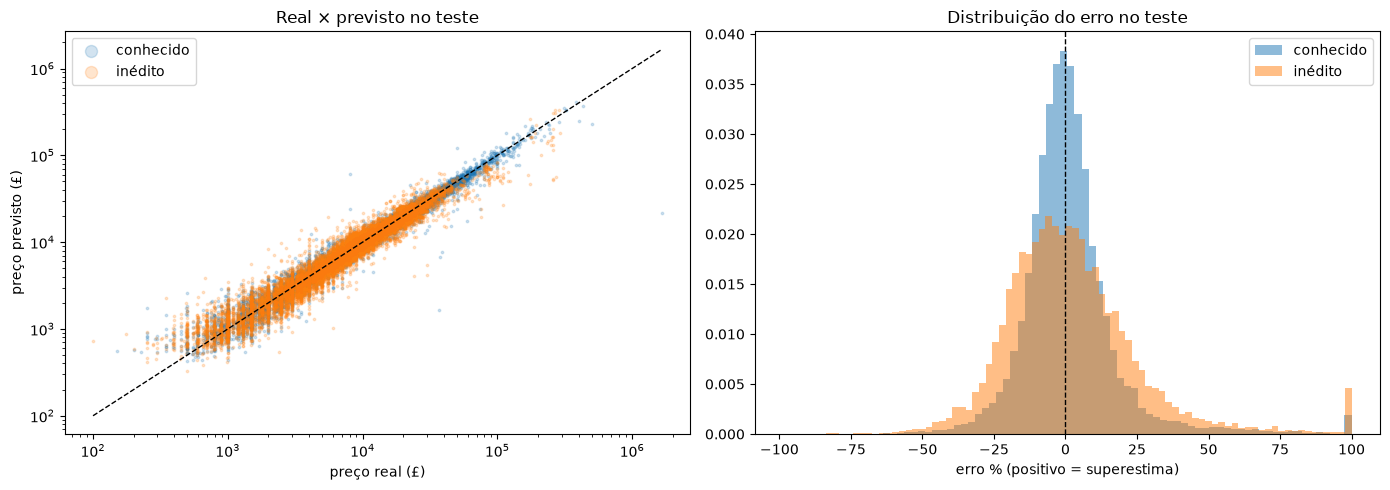

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Preço real × previsto (escala log). Pontos na linha tracejada = acerto perfeito
for tipo, cor in [("conhecido", "tab:blue"), ("inédito", "tab:orange")]:
    d = erros[erros["tipo"] == tipo]
    axes[0].scatter(d["price"], d["pred"], s=3, alpha=0.2, color=cor, label=tipo)
lim = [erros["price"].min(), erros["price"].max()]
axes[0].plot(lim, lim, "k--", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("preço real (£)")
axes[0].set_ylabel("preço previsto (£)")
axes[0].set_title("Real × previsto no teste")
axes[0].legend(markerscale=5)

# 2) Distribuição do erro % (cortada em ±100% para o gráfico ficar legível)
for tipo, cor in [("conhecido", "tab:blue"), ("inédito", "tab:orange")]:
    axes[1].hist(erros.loc[erros["tipo"] == tipo, "erro_pct"].clip(-100, 100), bins=80,
                 alpha=0.5, density=True, color=cor, label=tipo)
axes[1].axvline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("erro % (positivo = superestima)")
axes[1].set_title("Distribuição do erro no teste")
axes[1].legend()

plt.tight_layout()
plt.show()

**Resultado da análise de erros:**

**Conhecido × inédito:** o erro mediano quase dobra em carros inéditos (7,3% → 12,9%), mas o viés fica perto de zero nos dois (−0,3% e −0,6%). Ou seja, o modelo erra mais nos carros novos, mas **não tem tendência** de sugerir preços sempre acima ou sempre abaixo.

**Por faixa de preço, o modelo erra mais nos carros baratos:**
- **Abaixo de £2 mil:** erro mediano de 20,9% e viés de **+7,9%**: o modelo **superestima** os carros mais baratos.
- **Entre £5 mil e £50 mil** (a maioria dos anúncios): erro de 7–9%, sem viés.
- **Acima de £50 mil:** viés de **−5,5%**: o modelo **subestima** os carros mais caros.

Esse padrão de "puxar para o meio" (superestimar os baratos, subestimar os caros) é típico de modelos de regressão. Nos extremos há menos exemplos, e a previsão tende a se aproximar dos preços mais comuns.

**Por idade:** até 8 anos o erro fica estável em ~8%. Depois ele sobe: **14,1% (8–12 anos) e 20,1% (12+ anos)**. Em carros velhos, o preço depende cada vez mais do **estado de conservação** (batidas, manutenção, defeitos), que não está na base. Idade e preço baixo andam juntos: são os mesmos carros da faixa "< £2 mil".

**Por marca:** as marcas com mais erro são **Saab** (19,6%), **Renault** (15,8%) e **Nissan** (12,4%), e as três têm viés forte:
- Saab (−11,4%) e Renault (−11,8%): o modelo **subestima** o preço;
- Nissan (+10,8%): o modelo **superestima**.

A Saab parou de fabricar carros em 2011, então todos os seus anúncios são de carros velhos, justamente a faixa em que o modelo erra mais. Uma explicação possível para Renault e Nissan é que modelos de carro dessas marcas caíram no teste "inédito"; seria preciso cruzar marca × tipo para confirmar. As marcas com menor erro são Jaguar (5,9%), Toyota (6,9%) e Mazda (7,0%).

**Os 10 maiores erros** são quase todos **carros muito baratos (£100–£700)**, que o modelo previu entre £700 e £4.000. São os "carros para desmanche" vistos na limpeza: o preço baixo reflete o estado do carro (batido, com defeito), uma informação que o anúncio não tem. Duas exceções interessantes:
- **Westfield** (£7.995, previsto £60.667): é um carro esportivo montado em kit, de marca rara. O modelo provavelmente o "confundiu" com esportivos caros pela potência.
- **Reva** (£1.995, previsto £8.293): é um microcarro elétrico indiano. O modelo associa "elétrico" a carro caro, e esse é o contrário.

**Gráficos:** os pontos seguem a diagonal de acerto perfeito em toda a faixa de preços. O histograma do erro é centrado em zero, mais estreito nos carros conhecidos (azul) do que nos inéditos (laranja). O pico em +100% são os casos cortados no gráfico (erros acima de 100%), quase todos carros muito baratos. No canto inferior direito do primeiro gráfico há um anúncio de ~£1,6 milhão previsto em ~£20 mil: um hipercarro, categoria rara demais para o modelo aprender.

## Versão reserva do Modelo 1: sem o câmbio

**Por quê:** o modelo principal usa o câmbio (`auto`) como entrada. Se um anúncio não informar o câmbio, ou se o arquivo de avaliação vier sem essa coluna, o modelo principal recebe esse campo vazio e erra mais (o grupo mediu isso na seção de bases e colunas).

**Solução:** treinar uma segunda versão com as mesmas configurações, só que **sem** a coluna `auto`. Na previsão final, cada anúncio usa:
- o **modelo principal**, se tiver o câmbio;
- o **modelo reserva**, se não tiver.

Abaixo, comparamos no teste três situações. Nenhuma escolha é feita a partir desse teste: a decisão de ter duas versões foi tomada antes. A tabela só documenta o efeito.

In [66]:
FEATURES_PRECO_SEM_CAMBIO = [c for c in FEATURES_PRECO if c != "auto"]

# Treina a versão reserva com o mesmo treino + validação
X_trf_sc, _ = X_y_final(treino_final, FEATURES_PRECO_SEM_CAMBIO)
modelo_reserva = modelo_hgb().fit(X_trf_sc, y_trf)

linhas = []
for tipo, d, X, y in [("conhecido", teste_conhecido, X_tc, y_tc), ("inédito", teste_inedito, X_ti, y_ti)]:
    X_sem_cambio = X.copy()
    X_sem_cambio["auto"] = np.nan          # simula um arquivo de avaliação sem o câmbio

    linhas.append({
        "teste": tipo,
        "principal, com câmbio": metricas(modelo_principal, X, y)[0],
        "principal, câmbio apagado": metricas(modelo_principal, X_sem_cambio, y)[0],
        "reserva (nunca usou câmbio)": metricas(modelo_reserva, X[FEATURES_PRECO_SEM_CAMBIO], y)[0],
    })

print("RMSE em log(price) no teste:")
pd.DataFrame(linhas).set_index("teste").round(4)

RMSE em log(price) no teste:


,"principal, com câmbio","principal, câmbio apagado",reserva (nunca usou câmbio)
teste,,,
conhecido,0.1706,0.1848,0.1713
inédito,0.2334,0.2387,0.2365


In [68]:
# a função que será usada na FINAL — PREDICTION SECTION
def preparar(df_bruto):
    """Arquivo cru -> colunas limpas + features linha a linha (o mesmo para treino e avaliação)."""
    return criar_features(limpar(df_bruto))

def prever_preco(d_preparado):
    """Recebe a base já passada por preparar() e devolve o preço sugerido (£).
    Anúncios com câmbio -> modelo principal; sem câmbio -> modelo reserva."""
    d = est_final.transform(d_preparado)
    pred = np.exp(modelo_reserva.predict(d[FEATURES_PRECO_SEM_CAMBIO]))

    tem_cambio = d["auto"].notna().to_numpy()
    if tem_cambio.any():
        pred[tem_cambio] = np.exp(modelo_principal.predict(d.loc[tem_cambio, FEATURES_PRECO]))
    return pred


# Teste rápido: roda no arquivo de avaliação simulado (sem price e sem gearbox)
p = prever_preco(preparar(avaliacao_fake))
print("previsões:", len(p), "| sem NaN:", not np.isnan(p).any(), "| exemplo:", p[:5].round(0))

previsões: 300 | sem NaN: True | exemplo: [ 3632.  2699.  5673. 32723.  6459.]


**Resultado (RMSE em log no teste):**

| Teste | Principal, com câmbio | Principal, câmbio apagado | Reserva (sem câmbio) |
|---|---|---|---|
| Conhecido | **0,1706** | 0,1848 | 0,1713 |
| Inédito | **0,2334** | 0,2387 | 0,2365 |

- **Se o câmbio sumir, o modelo principal piora bastante:** 0,1706 → 0,1848 nos carros conhecidos (+8%). Ele aprendeu a contar com essa coluna.
- **A versão reserva recupera quase tudo:** 0,1713, praticamente igual ao principal com câmbio.
- **O câmbio, por si só, ajuda pouco:** a diferença entre o principal com câmbio e a reserva é de só 0,0007 (conhecido) e 0,003 (inédito). O perigo não está em não ter o câmbio, e sim em **treinar com ele e depois não recebê-lo**.

**Decisão confirmada:** anúncios com câmbio usam o modelo principal; anúncios sem câmbio usam a reserva. A função `prever_preco()` faz essa escolha automaticamente e já foi testada no arquivo de avaliação simulado (300 anúncios, nenhuma previsão vazia).

*Alternativa registrada:* como o ganho do câmbio é pequeno, usar só a versão reserva para todos os anúncios também seria uma opção razoável e mais simples. Mantivemos as duas versões porque cada anúncio recebe a melhor previsão possível com a informação que tem.

# Resumo do Modelo 1 — Preço

**Modelo final:** HistGradientBoostingRegressor (max_leaf_nodes = 31), prevendo `log(price)`, treinado em treino + validação. Existem duas versões: a **principal**, com o câmbio, e a **reserva**, sem ele.

**Pontuações de todos os modelos testados (validação, RMSE em log, média de conhecido e inédito):**

| Modelo | Melhor config | RMSE médio |
|---|---|---|
| **HistGradientBoosting** | max_leaf_nodes = 31 | **0,194** |
| HGB regularizado | lr = 0,05, min 50/folha, l2 = 1 | 0,194 (empate) |
| Rede neural (MLP) | camadas = (64, 32) | 0,208 |
| Random Forest | max_depth = 20 | 0,222 |
| Decision Tree | max_depth = 12 | 0,287 |
| Ridge | alpha = 0,1 | 0,290 |
| Lasso | alpha = 0,00001 | 0,290 |
| Baseline (mediana) | — | 0,997 |

**Cenário temporal (treino até 2020, anúncios de 2021):** HistGradientBoosting 0,175 (MAPE 13,4%), Random Forest 0,183, rede neural 0,221, Ridge 0,237.

**Desempenho final (teste, usado uma única vez):** MAPE de **11,2%** em modelos de carro conhecidos e **17,5%** em modelos inéditos.

**Principais decisões:**
- Alvo em log, porque o preço vai de £100 a £1,6 milhão e importa o erro relativo, não o absoluto;
- Validação e teste divididos em "conhecido" e "inédito", porque a base de avaliação tem outra composição;
- Escolha pela média de conhecido e inédito, para não favorecer modelos que decoram modelos de carro;
- Rede neural (gradiente descendente + backpropagation) testada: segundo lugar, pior que o boosting na validação e no cenário temporal;
- Boosting regularizado testado: empatou, então ficou a versão mais simples;
- Cenário temporal (anúncios de 2021) confirmou a escolha do boosting;
- `pct_of_list` removida (vazamento), duplicatas removidas antes da divisão, `EstatisticasRef` ajustada só no treino;
- Versão reserva sem câmbio, para anúncios que não informam a transmissão.

**Escopo de validade (onde confiar no modelo):**
- ✅ **Confiável:** carros de £5 mil a £50 mil, com até 8 anos, de modelos já presentes na base (erro mediano de ~7–9%).
- ⚠️ **Menos confiável:** modelos de carro inéditos (erro ~75% maior), anúncios de outro período (MAPE de 13,4% em 2021), carros com mais de 8 anos e marcas como Saab, Renault e Nissan.
- ❌ **Não confiável:** carros abaixo de £2 mil (o preço depende do estado do carro, que não está na base; o modelo superestima), hipercarros e marcas raras (Westfield, Reva), que têm poucos exemplos.

**Limitações:**
- A base não tem o estado de conservação, o histórico de manutenção nem os opcionais, fatores que pesam muito no preço de carros velhos e baratos;
- A régua de escolha de features usou parte dos anúncios que depois foram para o teste "inédito" (não os do teste "conhecido"), então o resultado inédito pode ser levemente otimista;
- O modelo puxa os extremos para o meio: carros muito baratos são superestimados e carros caros, subestimados.

In [69]:
# A frase-resumo do Modelo 1: "erra ~11% em carros conhecidos e ~17,5% em carros inéditos; erra mais nos carros baratos e velhos, porque o preço deles depende do estado do carro, que o anúncio não informa".
# Por que não aumentamos as árvores (o early stopping bateu em 1.000): o teste já tinha sido visto, e mudar o modelo depois disso seria escolher pelo teste.